In [17]:
import pandas as pd
from IPython.display import display
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATASET_ID = "sns_analysis"
LOCATION = "asia-northeast3"
MAX_BYTES = 1100 * 1024**2

SCHOOL_IDS = [
    1719, 369, 5372, 4516, 5520,
    4426, 271, 1478, 5491, 352
]

CHECK_TABLES = [
    "user_friend_count_history",
    "stg_acquisition_user",
    "accounts_user",
    "polls_questionset",
    "accounts_userquestionrecord",
]

client = bigquery.Client(
    project=PROJECT_ID,
    location=LOCATION,
)


def query_df(sql, query_parameters=None):
    query_parameters = query_parameters or []

    dry_config = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False,
        query_parameters=query_parameters,
    )

    dry_job = client.query(sql, job_config=dry_config)
    estimated_bytes = dry_job.total_bytes_processed or 0

    print(f"예상 처리량: {estimated_bytes / 1024**2:,.1f} MiB")

    if estimated_bytes > MAX_BYTES:
        raise RuntimeError("예상 처리량이 MAX_BYTES를 초과했습니다.")

    run_config = bigquery.QueryJobConfig(
        maximum_bytes_billed=MAX_BYTES,
        query_parameters=query_parameters,
    )

    return client.query(
        sql,
        job_config=run_config,
    ).to_dataframe(create_bqstorage_client=False)

/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf

from matplotlib import font_manager


# 운영체제별 한글 폰트 경로
font_paths = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc"
]

for font_path in font_paths:
    if Path(font_path).exists():
        font_manager.fontManager.addfont(font_path)

        korean_font = font_manager.FontProperties(
            fname=font_path
        ).get_name()

        plt.rcParams["font.family"] = korean_font
        break

plt.rcParams["axes.unicode_minus"] = False

In [19]:
schema_rows = []
table_rows = []

for table_name in CHECK_TABLES:
    table_fqn = f"{PROJECT_ID}.{DATASET_ID}.{table_name}"
    table = client.get_table(table_fqn)

    table_rows.append({
        "table_name": table_name,
        "table_type": table.table_type,
        "row_count": table.num_rows,
        "size_mib": (
            table.num_bytes / 1024**2
            if table.num_bytes is not None
            else None
        ),
        "modified_utc": table.modified,
    })

    for position, field in enumerate(table.schema, start=1):
        schema_rows.append({
            "table_name": table_name,
            "position": position,
            "column_name": field.name,
            "field_type": field.field_type,
            "mode": field.mode,
            "description": field.description,
        })

schema_df = pd.DataFrame(schema_rows)
table_meta_df = pd.DataFrame(table_rows)

display(table_meta_df)
display(schema_df)

,table_name,table_type,row_count,size_mib,modified_utc
0,user_friend_count_history,TABLE,25750890,982.318497,2026-09-18 04:10:48.640000+00:00
1,stg_acquisition_user,VIEW,0,0.000000,2026-09-08 05:59:52.029000+00:00
2,accounts_user,TABLE,677080,372.749567,2026-09-08 01:08:31.066000+00:00
3,polls_questionset,TABLE,158384,20.910929,2026-09-03 06:58:31.889000+00:00
4,accounts_userquestionrecord,TABLE,1217558,99.859226,2026-09-03 06:58:11.538000+00:00


,table_name,position,column_name,field_type,mode,description
0,user_friend_count_history,1,user_id,INTEGER,REQUIRED,None
1,user_friend_count_history,2,friend_user_id,INTEGER,REQUIRED,None
2,user_friend_count_history,3,friendship_at,TIMESTAMP,REQUIRED,None
3,user_friend_count_history,4,friend_cnt_before,INTEGER,REQUIRED,None
4,user_friend_count_history,5,friend_cnt_after,INTEGER,REQUIRED,None
5,stg_acquisition_user,1,user_id,INTEGER,NULLABLE,None
6,stg_acquisition_user,2,signup_date,TIMESTAMP,NULLABLE,None
7,stg_acquisition_user,3,group_id,INTEGER,NULLABLE,None
8,stg_acquisition_user,4,grade,INTEGER,NULLABLE,None
9,stg_acquisition_user,5,school_id,INTEGER,NULLABLE,None


In [20]:
friend_sample_sql = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.user_friend_count_history`
LIMIT 30
"""

school_map_sample_sql = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.stg_acquisition_user`
LIMIT 30
"""

questionset_f_sample_sql = f"""
SELECT *
FROM `{PROJECT_ID}.{DATASET_ID}.polls_questionset`
WHERE status = 'F'
LIMIT 30
"""

friend_sample_df = query_df(friend_sample_sql)
school_map_sample_df = query_df(school_map_sample_sql)
questionset_f_sample_df = query_df(questionset_f_sample_sql)

display(friend_sample_df)
display(school_map_sample_df)
display(questionset_f_sample_df)

예상 처리량: 982.3 MiB
예상 처리량: 17.6 MiB
예상 처리량: 20.9 MiB


,user_id,friend_user_id,friendship_at,friend_cnt_before,friend_cnt_after
0,838461,837749,2023-04-19 15:10:45+00:00,0,1
1,838992,838041,2023-04-20 07:18:41+00:00,0,1
2,843581,842347,2023-04-23 14:14:32+00:00,0,1
3,845057,846109,2023-05-01 06:58:57+00:00,0,1
4,846433,846040,2023-04-26 10:41:18+00:00,0,1
5,847192,846845,2023-04-26 09:51:18+00:00,0,1
6,850866,849497,2023-04-29 01:01:15+00:00,0,1
7,853063,852570,2023-04-29 12:37:36+00:00,0,1
8,1195203,1165305,2023-05-13 03:49:28+00:00,0,1
9,1197505,1084128,2023-05-13 04:51:49+00:00,0,1


,user_id,signup_date,group_id,grade,school_id,address,school_type
0,835057,2023-04-04 13:16:02.781676+00:00,85,1,4461,경기도 화성시,H
1,854727,2023-04-29 15:14:23.029107+00:00,5422,3,2050,서울특별시 송파구,M
2,859110,2023-04-30 12:04:42.352383+00:00,6505,1,2415,서울특별시 광진구,H
3,870552,2023-05-02 10:48:01.870657+00:00,9154,3,1625,인천광역시 남동구,H
4,904150,2023-05-06 10:22:36.543120+00:00,16332,1,3194,대구광역시 북구,H
5,908814,2023-05-06 11:44:40.001587+00:00,4046,2,273,충청남도 천안시 서북구,M
6,909190,2023-05-06 11:50:38.540885+00:00,5889,1,5239,경기도 성남시 분당구,H
7,912989,2023-05-06 12:43:52.702106+00:00,15794,3,5433,경기도 김포시,M
8,916680,2023-05-06 13:31:58.223527+00:00,18271,3,137,충청북도 진천군,M
9,936632,2023-05-07 02:24:07.220295+00:00,20768,2,5060,경기도 시흥시,H


,id,question_piece_id_list,opening_time,status,created_at,user_id
0,116704,"[1167328, 1167329, 1167330, 1167331, 1167332, ...",2023-04-29 10:02:26+00:00,F,2023-04-29 10:02:26+00:00,838023
1,132741,"[1327698, 1327699, 1327700, 1327701, 1327702, ...",2023-04-29 17:13:06+00:00,F,2023-04-29 16:23:06+00:00,838023
2,145316,"[1453448, 1453449, 1453450, 1453451, 1453452, ...",2023-04-30 05:09:03+00:00,F,2023-04-30 04:19:03+00:00,838023
3,257385,"[2574132, 2574133, 2574135, 2574137, 2574138, ...",2023-05-02 06:39:51+00:00,F,2023-05-02 05:49:51+00:00,838023
4,333471,"[3334998, 3334999, 3335000, 3335001, 3335002, ...",2023-05-03 09:26:09+00:00,F,2023-05-03 08:36:10+00:00,838023
5,347685,"[3477138, 3477139, 3477140, 3477141, 3477142, ...",2023-05-03 13:13:23+00:00,F,2023-05-03 12:23:23+00:00,838023
6,305901,"[3059298, 3059299, 3059300, 3059301, 3059302, ...",2023-05-02 22:41:59+00:00,F,2023-05-02 22:41:59+00:00,838466
7,305990,"[3060188, 3060189, 3060190, 3060191, 3060192, ...",2023-05-02 23:33:30+00:00,F,2023-05-02 22:43:30+00:00,838466
8,311952,"[3119808, 3119809, 3119810, 3119811, 3119812, ...",2023-05-03 01:35:07+00:00,F,2023-05-03 00:45:07+00:00,838466
9,326249,"[3262778, 3262779, 3262780, 3262781, 3262782, ...",2023-05-03 07:13:58+00:00,F,2023-05-03 06:23:58+00:00,838466


In [21]:
TIME_TYPES = {"DATE", "DATETIME", "TIMESTAMP"}

time_schema = schema_df[
    schema_df["field_type"].isin(TIME_TYPES)
].copy()


def make_range_sql(table_name, columns, scope, where_clause=""):
    range_items = []

    for column_name in columns:
        range_items.append(f"""
        STRUCT(
            '{column_name}' AS column_name,
            CAST(MIN(`{column_name}`) AS STRING) AS min_value,
            CAST(MAX(`{column_name}`) AS STRING) AS max_value,
            COUNT(`{column_name}`) AS non_null_rows
        )
        """)

    return f"""
    SELECT
        '{table_name}' AS table_name,
        '{scope}' AS scope,
        item.*
    FROM (
        SELECT [{",".join(range_items)}] AS items
        FROM `{PROJECT_ID}.{DATASET_ID}.{table_name}`
        {where_clause}
    ),
    UNNEST(items) AS item
    """


range_parts = []

for table_name, group in time_schema.groupby("table_name"):
    columns = group["column_name"].tolist()

    range_parts.append(
        make_range_sql(
            table_name=table_name,
            columns=columns,
            scope="all_rows",
        )
    )

questionset_time_columns = time_schema.loc[
    time_schema["table_name"].eq("polls_questionset"),
    "column_name",
].tolist()

if questionset_time_columns:
    range_parts.append(
        make_range_sql(
            table_name="polls_questionset",
            columns=questionset_time_columns,
            scope="status_F",
            where_clause="WHERE status = 'F'",
        )
    )

period_sql = "\nUNION ALL\n".join(range_parts)

period_df = query_df(period_sql)
period_df = period_df.sort_values(
    ["table_name", "scope", "column_name"]
).reset_index(drop=True)

display(period_df)

예상 처리량: 229.6 MiB


,table_name,scope,column_name,min_value,max_value,non_null_rows
0,accounts_user,all_rows,created_at,2023-03-29 05:18:56.162368+00,2024-05-09 08:31:17.710824+00,677080
1,accounts_userquestionrecord,all_rows,answer_updated_at,2023-04-28 12:27:49+00,2024-05-08 01:36:18+00,1217558
2,accounts_userquestionrecord,all_rows,created_at,2023-04-28 12:27:49+00,2024-05-08 01:36:18+00,1217558
3,polls_questionset,all_rows,created_at,2023-04-28 12:27:23+00,2024-05-07 11:32:30+00,158384
4,polls_questionset,all_rows,opening_time,2023-04-28 12:27:22+00,2024-05-07 12:12:30+00,158384
5,polls_questionset,status_F,created_at,2023-04-28 12:27:23+00,2024-03-19 12:53:58+00,153411
6,polls_questionset,status_F,opening_time,2023-04-28 12:27:22+00,2024-03-19 12:53:58+00,153411
7,stg_acquisition_user,all_rows,signup_date,2023-03-31 09:05:51.903699+00,2024-05-09 08:31:17.710824+00,676984
8,user_friend_count_history,all_rows,friendship_at,2023-04-18 19:28:41+00,2024-05-09 07:33:06+00,25750890


# 검증

## 1. 10개 학교 전체 소속 사용자

In [22]:
school_ids_sql = ", ".join(map(str, SCHOOL_IDS))

population_sql = f"""
SELECT
    user_id,
    signup_date,
    group_id,
    grade,
    school_id,
    school_type
FROM `{PROJECT_ID}.{DATASET_ID}.stg_acquisition_user`
WHERE school_id IN ({school_ids_sql})
"""

population_df = query_df(population_sql)

population_df["signup_date"] = pd.to_datetime(
    population_df["signup_date"],
    utc=True,
)

population_df = population_df.sort_values(
    ["school_id", "signup_date", "user_id"]
).reset_index(drop=True)

예상 처리량: 17.5 MiB


In [23]:
actual_school_ids = set(
    population_df["school_id"].dropna().astype(int)
)

missing_school_ids = sorted(
    set(SCHOOL_IDS) - actual_school_ids
)

population_qa = pd.Series({
    "전체 사용자 수": population_df["user_id"].nunique(),
    "학교 수": population_df["school_id"].nunique(),
    "학급 수": population_df["group_id"].nunique(),
    "user_id 중복 행": population_df["user_id"].duplicated().sum(),
    "가입일 결측": population_df["signup_date"].isna().sum(),
    "group_id 결측": population_df["group_id"].isna().sum(),
    "누락 학교 ID": missing_school_ids,
})

school_summary = (
    population_df
    .groupby("school_id", as_index=False)
    .agg(
        user_count=("user_id", "nunique"),
        group_count=("group_id", "nunique"),
        first_signup_at=("signup_date", "min"),
        last_signup_at=("signup_date", "max"),
    )
    .sort_values("school_id")
)

display(population_qa)
display(school_summary)

if population_df["user_id"].duplicated().any():
    raise ValueError("stg_acquisition_user에 user_id 중복이 있습니다.")

if missing_school_ids:
    raise ValueError(f"조회되지 않은 학교가 있습니다: {missing_school_ids}")

전체 사용자 수        5090
학교 수              10
학급 수             353
user_id 중복 행       0
가입일 결측             0
group_id 결측        0
누락 학교 ID          []
dtype: object

,school_id,user_count,group_count,first_signup_at,last_signup_at
0,271,492,41,2023-04-19 09:06:00.719792+00:00,2023-09-13 16:06:38.453835+00:00
1,352,491,37,2023-04-24 04:10:12.095185+00:00,2023-09-23 08:52:16.138685+00:00
2,369,578,39,2023-04-19 15:10:56.560337+00:00,2024-04-22 04:54:45.332573+00:00
3,1478,488,30,2023-05-05 10:51:32.513375+00:00,2023-08-01 11:51:13.811964+00:00
4,1719,551,31,2023-05-07 14:15:09.397548+00:00,2024-03-06 12:00:24.208601+00:00
5,4426,487,35,2023-04-29 16:06:03.134614+00:00,2023-06-18 03:14:36.399002+00:00
6,4516,510,37,2023-04-29 14:23:17.790839+00:00,2023-09-20 15:30:13.114964+00:00
7,5372,507,37,2023-05-07 02:33:46.412013+00:00,2023-12-06 14:44:01.270373+00:00
8,5491,486,36,2023-04-22 13:39:28.230920+00:00,2023-11-18 15:12:55.132769+00:00
9,5520,500,30,2023-05-06 08:51:06.377706+00:00,2024-03-19 12:53:37.705774+00:00


## 2. 대상자의 친구 이력과 현재 친구 수 조회

In [24]:
target_user_ids = (
    population_df["user_id"]
    .dropna()
    .astype("int64")
    .unique()
    .tolist()
)

target_user_parameter = [
    bigquery.ArrayQueryParameter(
        "target_user_ids",
        "INT64",
        target_user_ids,
    )
]

In [25]:
friend_history_sql = f"""
SELECT
    user_id,
    friend_user_id,
    friendship_at,
    friend_cnt_before,
    friend_cnt_after
FROM `{PROJECT_ID}.{DATASET_ID}.user_friend_count_history`
WHERE user_id IN UNNEST(@target_user_ids)
"""

friend_history_df = query_df(
    friend_history_sql,
    target_user_parameter,
)

friend_history_df["friendship_at"] = pd.to_datetime(
    friend_history_df["friendship_at"],
    utc=True,
)

예상 처리량: 982.3 MiB


In [26]:
current_friend_sql = f"""
SELECT
    id AS user_id,
    ARRAY_LENGTH(
        JSON_QUERY_ARRAY(friend_id_list)
    ) AS current_friend_count
FROM `{PROJECT_ID}.{DATASET_ID}.accounts_user`
WHERE id IN UNNEST(@target_user_ids)
"""

current_friend_count_df = query_df(
    current_friend_sql,
    target_user_parameter,
)

예상 처리량: 307.8 MiB


## 3. 친구 수 이력 검증

In [27]:
friend_history_df = (
    friend_history_df
    .merge(
        population_df[["user_id", "signup_date"]],
        on="user_id",
        how="left",
        validate="many_to_one",
    )
    .sort_values([
        "user_id",
        "friendship_at",
        "friend_cnt_before",
        "friend_cnt_after",
    ])
    .reset_index(drop=True)
)

friend_history_df["friend_change"] = (
    friend_history_df["friend_cnt_after"]
    - friend_history_df["friend_cnt_before"]
)

friend_history_df["previous_after"] = (
    friend_history_df
    .groupby("user_id")["friend_cnt_after"]
    .shift()
)

friend_history_df["chain_break_flag"] = (
    friend_history_df["previous_after"].notna()
    & friend_history_df["friend_cnt_before"].ne(
        friend_history_df["previous_after"]
    )
)

friend_history_df["duplicate_time_flag"] = (
    friend_history_df.duplicated(
        ["user_id", "friendship_at"],
        keep=False,
    )
)

friend_history_df["exact_duplicate_flag"] = (
    friend_history_df.duplicated(
        [
            "user_id",
            "friend_user_id",
            "friendship_at",
            "friend_cnt_before",
            "friend_cnt_after",
        ],
        keep=False,
    )
)

friend_history_df["pre_signup_flag"] = (
    friend_history_df["friendship_at"]
    < friend_history_df["signup_date"]
)

friend_history_df["negative_count_flag"] = (
    friend_history_df["friend_cnt_before"].lt(0)
    | friend_history_df["friend_cnt_after"].lt(0)
)

In [28]:
# 유저별 이력 품질
friend_user_stats = (
    friend_history_df
    .groupby("user_id", as_index=False)
    .agg(
        history_rows=("user_id", "size"),
        first_friendship_at=("friendship_at", "min"),
        last_friendship_at=("friendship_at", "max"),
        first_before=("friend_cnt_before", "first"),
        last_after=("friend_cnt_after", "last"),
        decrease_rows=(
            "friend_change",
            lambda x: x.lt(0).sum(),
        ),
        chain_break_rows=("chain_break_flag", "sum"),
        duplicate_time_rows=("duplicate_time_flag", "sum"),
        exact_duplicate_rows=("exact_duplicate_flag", "sum"),
        pre_signup_rows=("pre_signup_flag", "sum"),
        negative_count_rows=("negative_count_flag", "sum"),
    )
)

friend_user_qa = (
    population_df[["user_id", "signup_date"]]
    .merge(
        friend_user_stats,
        on="user_id",
        how="left",
    )
    .merge(
        current_friend_count_df,
        on="user_id",
        how="left",
        validate="one_to_one",
    )
)

In [29]:
count_columns = [
    "history_rows",
    "decrease_rows",
    "chain_break_rows",
    "duplicate_time_rows",
    "exact_duplicate_rows",
    "pre_signup_rows",
    "negative_count_rows",
]

friend_user_qa[count_columns] = (
    friend_user_qa[count_columns]
    .fillna(0)
    .astype(int)
)

friend_user_qa["expected_current_count"] = (
    friend_user_qa["last_after"].fillna(0)
)

friend_user_qa["first_state_ok"] = (
    friend_user_qa["history_rows"].eq(0)
    | friend_user_qa["first_before"].eq(0)
)

friend_user_qa["current_count_match"] = (
    friend_user_qa["current_friend_count"].notna()
    & friend_user_qa["expected_current_count"].eq(
        friend_user_qa["current_friend_count"]
    )
)

friend_user_qa["friend_history_valid"] = (
    friend_user_qa["signup_date"].notna()
    & friend_user_qa["first_state_ok"]
    & friend_user_qa["chain_break_rows"].eq(0)
    & friend_user_qa["duplicate_time_rows"].eq(0)
    & friend_user_qa["exact_duplicate_rows"].eq(0)
    & friend_user_qa["pre_signup_rows"].eq(0)
    & friend_user_qa["negative_count_rows"].eq(0)
    & friend_user_qa["current_count_match"]
)

#### 검증 결과

In [30]:
friend_validation_summary = pd.Series({
    "친구 이력 행 수": len(friend_history_df),
    "친구 이력 보유 유저": friend_history_df["user_id"].nunique(),
    "친구 수 감소 행": friend_history_df["friend_change"].lt(0).sum(),
    "상태 연결 불일치 행": friend_history_df["chain_break_flag"].sum(),
    "동일 유저·동일 시각 행": friend_history_df["duplicate_time_flag"].sum(),
    "완전 중복 행": friend_history_df["exact_duplicate_flag"].sum(),
    "가입 전 친구 이벤트": friend_history_df["pre_signup_flag"].sum(),
    "현재 친구 수 불일치 유저": (
        ~friend_user_qa["current_count_match"]
    ).sum(),
    "T0 복원 가능 친구 이력 유저": (
        friend_user_qa["friend_history_valid"]
    ).sum(),
    "T0 복원 불가 친구 이력 유저": (
        ~friend_user_qa["friend_history_valid"]
    ).sum(),
})

transition_summary = (
    friend_history_df["friend_change"]
    .value_counts()
    .sort_index()
    .rename_axis("friend_change")
    .reset_index(name="row_count")
)

display(friend_validation_summary)
display(transition_summary)

display(
    friend_user_qa.loc[
        ~friend_user_qa["friend_history_valid"]
    ].head(20)
)

친구 이력 행 수            221675
친구 이력 보유 유저            4980
친구 수 감소 행                 0
상태 연결 불일치 행               0
동일 유저·동일 시각 행         20683
완전 중복 행                   0
가입 전 친구 이벤트               0
현재 친구 수 불일치 유저         5054
T0 복원 가능 친구 이력 유저        22
T0 복원 불가 친구 이력 유저      5068
dtype: int64

,friend_change,row_count
0,1,221675


,user_id,signup_date,history_rows,first_friendship_at,last_friendship_at,first_before,last_after,decrease_rows,chain_break_rows,duplicate_time_rows,exact_duplicate_rows,pre_signup_rows,negative_count_rows,current_friend_count,expected_current_count,first_state_ok,current_count_match,friend_history_valid
0,838023,2023-04-19 09:06:00.719792+00:00,0,NaT,NaT,<NA>,<NA>,0,0,0,0,0,0,52,0,True,False,False
1,838642,2023-04-20 00:11:00.962160+00:00,6,2023-04-28 14:23:52+00:00,2023-05-06 07:10:35+00:00,0,6,0,0,0,0,0,0,79,6,True,False,False
2,839357,2023-04-20 14:26:20.479856+00:00,53,2023-04-29 16:55:18+00:00,2023-05-02 15:56:13+00:00,0,53,0,0,9,0,0,0,81,53,True,False,False
3,839670,2023-04-21 00:25:27.279382+00:00,1,2023-04-21 00:28:21+00:00,2023-04-21 00:28:21+00:00,0,1,0,0,0,0,0,0,31,1,True,False,False
4,845238,2023-04-24 22:15:16.785006+00:00,71,2023-04-29 16:04:45+00:00,2023-06-06 08:27:09+00:00,0,71,0,0,6,0,0,0,82,71,True,False,False
5,847375,2023-04-26 11:32:36.470049+00:00,124,2023-04-28 02:56:35+00:00,2023-05-10 06:13:12+00:00,0,124,0,0,12,0,0,0,165,124,True,False,False
6,849103,2023-04-27 13:45:23.532923+00:00,98,2023-04-27 15:24:45+00:00,2023-05-28 20:51:35+00:00,0,98,0,0,6,0,0,0,128,98,True,False,False
7,849436,2023-04-28 02:54:59.981972+00:00,88,2023-04-28 02:56:36+00:00,2023-06-04 13:47:22+00:00,0,88,0,0,2,0,0,0,98,88,True,False,False
8,849438,2023-04-28 02:56:02.571340+00:00,115,2023-04-28 02:56:35+00:00,2023-05-23 15:35:33+00:00,0,115,0,0,10,0,0,0,131,115,True,False,False
9,849439,2023-04-28 02:56:34.379981+00:00,75,2023-04-28 02:57:05+00:00,2023-05-04 10:20:30+00:00,0,75,0,0,27,0,0,0,104,75,True,False,False


## 4. 학교 40명 도달 시점

In [31]:
school_signup_order = (
    population_df
    .dropna(subset=["signup_date"])
    .sort_values(["school_id", "signup_date", "user_id"])
    .copy()
)

school_signup_order["school_signup_order"] = (
    school_signup_order
    .groupby("school_id")
    .cumcount()
    .add(1)
)

school_40_df = (
    school_signup_order.loc[
        school_signup_order["school_signup_order"].eq(40),
        ["school_id", "signup_date"],
    ]
    .rename(columns={
        "signup_date": "school_40_at"
    })
)

display(school_40_df)

,school_id,school_40_at
39,271,2023-04-28 03:43:18.503902+00:00
531,352,2023-05-05 04:07:00.053881+00:00
1022,369,2023-05-02 22:44:27.267798+00:00
1600,1478,2023-05-06 14:18:58.057918+00:00
2088,1719,2023-05-13 08:00:50.712386+00:00
2639,4426,2023-05-16 00:18:41.426463+00:00
3126,4516,2023-05-02 15:17:04.497555+00:00
3636,5372,2023-05-10 23:47:35.094548+00:00
4143,5491,2023-05-07 02:57:28.039304+00:00
4629,5520,2023-05-08 13:49:27.604223+00:00


# 최소 검증

## 1. 친구 수 후보 값 비교

In [32]:
history_check_df = (
    friend_history_df
    .sort_values([
        "user_id",
        "friendship_at",
        "friend_cnt_before",
        "friend_cnt_after",
    ])
    .copy()
)

history_check_df["duplicate_pair_flag"] = (
    history_check_df.duplicated(
        ["user_id", "friend_user_id"],
        keep=False,
    )
)

friend_user_compare = (
    history_check_df
    .groupby("user_id", as_index=False)
    .agg(
        history_rows=("friend_user_id", "size"),
        unique_friend_users=("friend_user_id", "nunique"),
        unique_friendship_times=("friendship_at", "nunique"),
        max_friend_cnt_after=("friend_cnt_after", "max"),
        last_friend_cnt_after=("friend_cnt_after", "last"),
        duplicate_pair_rows=("duplicate_pair_flag", "sum"),
    )
)

friend_user_compare = (
    population_df[["user_id"]]
    .merge(
        friend_user_compare,
        on="user_id",
        how="left",
    )
    .merge(
        current_friend_count_df,
        on="user_id",
        how="left",
        validate="one_to_one",
    )
)

In [33]:
history_metric_columns = [
    "history_rows",
    "unique_friend_users",
    "unique_friendship_times",
    "max_friend_cnt_after",
    "last_friend_cnt_after",
    "duplicate_pair_rows",
]

friend_user_compare[history_metric_columns] = (
    friend_user_compare[history_metric_columns]
    .fillna(0)
    .astype(int)
)

friend_compare_summary = pd.Series({
    "전체 사용자": len(friend_user_compare),
    "현재 친구 수 결측": (
        friend_user_compare["current_friend_count"].isna().sum()
    ),
    "현재 수 = 이력 행 수": (
        friend_user_compare["current_friend_count"]
        .eq(friend_user_compare["history_rows"])
        .sum()
    ),
    "현재 수 = 고유 친구 수": (
        friend_user_compare["current_friend_count"]
        .eq(friend_user_compare["unique_friend_users"])
        .sum()
    ),
    "현재 수 = friend_cnt_after 최대값": (
        friend_user_compare["current_friend_count"]
        .eq(friend_user_compare["max_friend_cnt_after"])
        .sum()
    ),
    "현재 수 = 마지막 friend_cnt_after": (
        friend_user_compare["current_friend_count"]
        .eq(friend_user_compare["last_friend_cnt_after"])
        .sum()
    ),
    "동일 친구 중복 이력 유저": (
        friend_user_compare["duplicate_pair_rows"].gt(0).sum()
    ),
})

display(friend_compare_summary)

전체 사용자                         5090
현재 친구 수 결측                        0
현재 수 = 이력 행 수                    36
현재 수 = 고유 친구 수                   36
현재 수 = friend_cnt_after 최대값      36
현재 수 = 마지막 friend_cnt_after      36
동일 친구 중복 이력 유저                    0
dtype: int64

## 2. 차이 크기 확인

In [34]:
for column in [
    "history_rows",
    "unique_friend_users",
    "max_friend_cnt_after",
    "last_friend_cnt_after",
]:
    friend_user_compare[f"{column}_diff"] = (
        friend_user_compare[column]
        - friend_user_compare["current_friend_count"]
    )

difference_summary = (
    friend_user_compare[
        [
            "history_rows_diff",
            "unique_friend_users_diff",
            "max_friend_cnt_after_diff",
            "last_friend_cnt_after_diff",
        ]
    ]
    .describe()
    .T
)

display(difference_summary)

,count,mean,std,min,25%,50%,75%,max
history_rows_diff,5090.0,-15.629077,15.101554,-136.0,-19.0,-11.0,-6.0,1.0
unique_friend_users_diff,5090.0,-15.629077,15.101554,-136.0,-19.0,-11.0,-6.0,1.0
max_friend_cnt_after_diff,5090.0,-15.629077,15.101554,-136.0,-19.0,-11.0,-6.0,1.0
last_friend_cnt_after_diff,5090.0,-15.629077,15.101554,-136.0,-19.0,-11.0,-6.0,1.0


In [35]:
display(
    friend_user_compare[
        [
            "user_id",
            "current_friend_count",
            "history_rows",
            "unique_friend_users",
            "max_friend_cnt_after",
            "last_friend_cnt_after",
            "duplicate_pair_rows",
        ]
    ].head(30)
)

,user_id,current_friend_count,history_rows,unique_friend_users,max_friend_cnt_after,last_friend_cnt_after,duplicate_pair_rows
0,838023,52,0,0,0,0,0
1,838642,79,6,6,6,6,0
2,839357,81,53,53,53,53,0
3,839670,31,1,1,1,1,0
4,845238,82,71,71,71,71,0
5,847375,165,124,124,124,124,0
6,849103,128,98,98,98,98,0
7,849436,98,88,88,88,88,0
8,849438,131,115,115,115,115,0
9,849439,104,75,75,75,75,0


## 3. 동일 유저·동일 시각 행이 정상적인 묶음인지 확인

In [36]:
same_time_qa = (
    history_check_df
    .groupby(
        ["user_id", "friendship_at"],
        as_index=False,
    )
    .agg(
        row_count=("friend_user_id", "size"),
        unique_friend_users=("friend_user_id", "nunique"),
        min_before=("friend_cnt_before", "min"),
        max_before=("friend_cnt_before", "max"),
        min_after=("friend_cnt_after", "min"),
        max_after=("friend_cnt_after", "max"),
        unique_before=("friend_cnt_before", "nunique"),
        unique_after=("friend_cnt_after", "nunique"),
    )
)

same_time_qa["sequential_batch_flag"] = (
    same_time_qa["max_after"]
    .sub(same_time_qa["min_before"])
    .eq(same_time_qa["row_count"])
    & same_time_qa["unique_before"].eq(
        same_time_qa["row_count"]
    )
    & same_time_qa["unique_after"].eq(
        same_time_qa["row_count"]
    )
    & same_time_qa["unique_friend_users"].eq(
        same_time_qa["row_count"]
    )
)

In [37]:
same_time_summary = pd.Series({
    "유저·시각 묶음 수": len(same_time_qa),
    "2행 이상 묶음 수": (
        same_time_qa["row_count"].gt(1).sum()
    ),
    "정상 연속 묶음 수": (
        same_time_qa["sequential_batch_flag"].sum()
    ),
    "비정상 묶음 수": (
        ~same_time_qa["sequential_batch_flag"]
    ).sum(),
})

display(same_time_summary)

display(
    same_time_qa
    .sort_values("row_count", ascending=False)
    .head(20)
)

유저·시각 묶음 수    210954
2행 이상 묶음 수      9962
정상 연속 묶음 수    210954
비정상 묶음 수           0
dtype: int64

,user_id,friendship_at,row_count,unique_friend_users,min_before,max_before,min_after,max_after,unique_before,unique_after,sequential_batch_flag
26825,874151,2023-05-05 13:23:43+00:00,5,5,10,14,11,15,5,5,True
24914,873496,2023-05-06 09:19:44+00:00,5,5,17,21,18,22,5,5,True
61506,887050,2023-05-06 04:43:43+00:00,4,4,35,38,36,39,4,4,True
130380,1167792,2023-05-13 22:23:46+00:00,4,4,30,33,31,34,4,4,True
34234,875824,2023-05-03 13:19:06+00:00,4,4,11,14,12,15,4,4,True
72642,914594,2023-05-14 05:45:33+00:00,4,4,56,59,57,60,4,4,True
76667,924088,2023-05-27 11:28:17+00:00,4,4,57,60,58,61,4,4,True
62053,887358,2023-05-10 06:10:32+00:00,4,4,38,41,39,42,4,4,True
32636,875373,2023-05-17 13:14:13+00:00,4,4,85,88,86,89,4,4,True
72982,915060,2023-05-10 14:47:25+00:00,4,4,139,142,140,143,4,4,True


## 4. 동일 친구 중복 여부

In [38]:
friend_pair_qa = (
    history_check_df
    .groupby(
        ["user_id", "friend_user_id"],
        as_index=False,
    )
    .agg(
        row_count=("friendship_at", "size"),
        first_friendship_at=("friendship_at", "min"),
        last_friendship_at=("friendship_at", "max"),
    )
)

friend_pair_summary = pd.Series({
    "고유 유저·친구 조합": len(friend_pair_qa),
    "중복 조합 수": friend_pair_qa["row_count"].gt(1).sum(),
    "조합당 최대 행 수": friend_pair_qa["row_count"].max(),
})

display(friend_pair_summary)

display(
    friend_pair_qa.loc[
        friend_pair_qa["row_count"].gt(1)
    ].head(20)
)

고유 유저·친구 조합    221675
중복 조합 수             0
조합당 최대 행 수          1
dtype: int64

,user_id,friend_user_id,row_count,first_friendship_at,last_friendship_at


In [39]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
LOCATION = "asia-northeast3"
MAX_BYTES_BILLED = 1100 * 1024**2

client = bigquery.Client(
    project=PROJECT_ID,
    location=LOCATION
)

sql_friend_columns = """
SELECT
    table_name,
    ordinal_position,
    column_name,
    data_type
FROM `sns-analysis-prj.sns_analysis.INFORMATION_SCHEMA.COLUMNS`
WHERE
    REGEXP_CONTAINS(
        LOWER(column_name),
        r'friend|unfriend|remove|delete'
    )
    OR table_name IN (
        'events',
        'mart_after_signup_event',
        'mart_user_activation',
        'mart_user_daily_state_analysis'
    )
ORDER BY table_name, ordinal_position
"""

job_config = bigquery.QueryJobConfig(
    maximum_bytes_billed=MAX_BYTES_BILLED
)

query_job = client.query(
    sql_friend_columns,
    location=LOCATION,
    job_config=job_config
)

friend_column_check_df = (
    query_job.result()
    .to_dataframe(create_bqstorage_client=False)
)

friend_column_check_df

/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


,table_name,ordinal_position,column_name,data_type
0,accounts_user,6,friend_id_list,STRING
1,events,1,id,INT64
2,events,2,title,STRING
3,events,3,plus_point,INT64
4,events,4,event_type,STRING
...,...,...,...,...
80,mart_user_weekly_analysis,10,friend_count,INT64
81,user_friend_count_history,2,friend_user_id,INT64
82,user_friend_count_history,3,friendship_at,TIMESTAMP
83,user_friend_count_history,4,friend_cnt_before,INT64


In [40]:
friend_related_columns_df = friend_column_check_df[
    friend_column_check_df["column_name"].str.contains(
        r"friend|unfriend|remove|delete",
        case=False,
        regex=True,
        na=False
    )
].reset_index(drop=True)

friend_related_columns_df

,table_name,ordinal_position,column_name,data_type
0,accounts_user,6,friend_id_list,STRING
1,hackle_events,8,friend_count,FLOAT64
2,mart_after_signup_event,6,friend_count,FLOAT64
3,mart_user_weekly_analysis,10,friend_count,INT64
4,user_friend_count_history,2,friend_user_id,INT64
5,user_friend_count_history,3,friendship_at,TIMESTAMP
6,user_friend_count_history,4,friend_cnt_before,INT64
7,user_friend_count_history,5,friend_cnt_after,INT64


In [41]:
check_tables = [
    "mart_after_signup_event",
    "mart_user_activation",
    "mart_user_daily_state_analysis"
]

for table in check_tables:
    print(f"\n[{table}]")
    display(
        friend_column_check_df.loc[
            friend_column_check_df["table_name"].eq(table),
            ["ordinal_position", "column_name", "data_type"]
        ].reset_index(drop=True)
    )


[mart_after_signup_event]


,ordinal_position,column_name,data_type
0,1,user_id,STRING
1,2,event_datetime,TIMESTAMP
2,3,event_key,STRING
3,4,item_name,STRING
4,5,page_name,STRING
5,6,friend_count,FLOAT64
6,7,votes_count,FLOAT64
7,8,heart_balance,FLOAT64
8,9,question_id,FLOAT64



[mart_user_activation]


,ordinal_position,column_name,data_type
0,1,user_id,INT64
1,2,signup_at,TIMESTAMP
2,3,group_id,INT64
3,4,school_id,INT64
4,5,questionset_count,INT64
5,6,first_questionset_at,TIMESTAMP
6,7,last_questionset_at,TIMESTAMP
7,8,vote_count,INT64
8,9,first_vote_at,TIMESTAMP
9,10,last_vote_at,TIMESTAMP



[mart_user_daily_state_analysis]


,ordinal_position,column_name,data_type
0,1,user_id,INT64
1,2,activity_date,DATE
2,3,week_start,DATE
3,4,analysis_phase,STRING
4,5,anchor_cohort_flag,INT64
5,6,signup_date,DATE
6,7,user_tenure_days,INT64
7,8,gender,STRING
8,9,group_id,INT64
9,10,school_id,INT64


## 5. 친구삭제를 고려하지 않은 T0

In [42]:
sql_t0 = """
WITH target_users AS (
    SELECT
        user_id,
        signup_date,
        group_id,
        school_id
    FROM `sns-analysis-prj.sns_analysis.stg_acquisition_user`
    WHERE school_id IN (
        1719, 369, 5372, 4516, 5520,
        4426, 271, 1478, 5491, 352
    )
),

school_signup_order AS (
    SELECT
        school_id,
        user_id,
        signup_date,
        COUNT(*) OVER (
            PARTITION BY school_id
            ORDER BY signup_date, user_id
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_school_users
    FROM target_users
),

school_threshold AS (
    SELECT
        school_id,
        MIN(signup_date) AS school_40_at
    FROM school_signup_order
    WHERE cumulative_school_users >= 40
    GROUP BY school_id
),

friend_threshold AS (
    SELECT
        h.user_id,
        MIN(h.friendship_at) AS friend_4_at
    FROM `sns-analysis-prj.sns_analysis.user_friend_count_history` AS h
    INNER JOIN target_users AS u
        ON h.user_id = u.user_id
    WHERE h.friend_cnt_after >= 4
    GROUP BY h.user_id
)

SELECT
    u.user_id,
    u.signup_date,
    u.group_id,
    u.school_id,
    s.school_40_at,
    f.friend_4_at,
    CASE
        WHEN f.friend_4_at IS NULL THEN NULL
        ELSE GREATEST(s.school_40_at, f.friend_4_at)
    END AS t0_at,
    CASE
        WHEN f.friend_4_at IS NULL THEN 'friend_4_not_reached'
        ELSE 't0_observed'
    END AS t0_status
FROM target_users AS u
LEFT JOIN school_threshold AS s
    ON u.school_id = s.school_id
LEFT JOIN friend_threshold AS f
    ON u.user_id = f.user_id
ORDER BY u.user_id
"""

In [43]:
dry_config = bigquery.QueryJobConfig(
    dry_run=True,
    use_query_cache=False
)

dry_job = client.query(
    sql_t0,
    location=LOCATION,
    job_config=dry_config
)

print(f"예상 조회량: {dry_job.total_bytes_processed / 1024**2:,.1f} MiB")

예상 조회량: 606.2 MiB


In [44]:
job_config = bigquery.QueryJobConfig(
    maximum_bytes_billed=1100 * 1024**2
)

t0_base_df = (
    client.query(
        sql_t0,
        location=LOCATION,
        job_config=job_config
    )
    .result()
    .to_dataframe(create_bqstorage_client=False)
)

t0_base_df.head()

,user_id,signup_date,group_id,school_id,school_40_at,friend_4_at,t0_at,t0_status
0,838023,2023-04-19 09:06:00.719792+00:00,233,271,2023-04-28 03:43:18.503902+00:00,NaT,NaT,friend_4_not_reached
1,838466,2023-04-19 15:10:56.560337+00:00,321,369,2023-05-02 22:44:27.267798+00:00,2023-05-01 14:10:16+00:00,2023-05-02 22:44:27.267798+00:00,t0_observed
2,838642,2023-04-20 00:11:00.962160+00:00,356,271,2023-04-28 03:43:18.503902+00:00,2023-05-05 07:21:24+00:00,2023-05-05 07:21:24+00:00,t0_observed
3,839357,2023-04-20 14:26:20.479856+00:00,519,271,2023-04-28 03:43:18.503902+00:00,2023-04-29 16:55:27+00:00,2023-04-29 16:55:27+00:00,t0_observed
4,839670,2023-04-21 00:25:27.279382+00:00,603,271,2023-04-28 03:43:18.503902+00:00,NaT,NaT,friend_4_not_reached


In [45]:
t0_user_df = t0_base_df[
    t0_base_df["t0_at"].notna()
].copy()

t0_summary = pd.Series({
    "전체 대상 사용자": len(t0_base_df),
    "T0 관측 사용자": len(t0_user_df),
    "친구 4명 미도달": t0_base_df["t0_at"].isna().sum(),
    "학교 수": t0_base_df["school_id"].nunique(),
    "학급 수": t0_base_df["group_id"].nunique(),
    "user_id 중복": t0_base_df["user_id"].duplicated().sum(),
    "T0가 가입보다 이른 사용자": (
        t0_user_df["t0_at"] < t0_user_df["signup_date"]
    ).sum(),
    "최초 T0": t0_user_df["t0_at"].min(),
    "마지막 T0": t0_user_df["t0_at"].max()
})

t0_summary

전체 대상 사용자                                      5090
T0 관측 사용자                                      4880
친구 4명 미도달                                       210
학교 수                                             10
학급 수                                            353
user_id 중복                                        0
T0가 가입보다 이른 사용자                                   0
최초 T0              2023-04-28 03:43:18.503902+00:00
마지막 T0                    2023-11-11 07:53:32+00:00
dtype: object

### 1. 학교별 T0 커버리지

In [46]:
school_t0_qa = (
    t0_base_df
    .groupby("school_id", as_index=False)
    .agg(
        population_users=("user_id", "nunique"),
        group_count=("group_id", "nunique"),
        t0_users=("t0_at", lambda x: x.notna().sum()),
        school_40_at=("school_40_at", "min"),
        first_t0_at=("t0_at", "min"),
        last_t0_at=("t0_at", "max")
    )
)

school_t0_qa["t0_coverage"] = (
    school_t0_qa["t0_users"]
    / school_t0_qa["population_users"]
)

school_t0_qa

,school_id,population_users,group_count,t0_users,school_40_at,first_t0_at,last_t0_at,t0_coverage
0,271,492,41,459,2023-04-28 03:43:18.503902+00:00,2023-04-28 03:43:18.503902+00:00,2023-07-11 09:43:57+00:00,0.932927
1,352,491,37,467,2023-05-05 04:07:00.053881+00:00,2023-05-05 04:07:00.053881+00:00,2023-11-11 07:53:32+00:00,0.951120
2,369,578,39,547,2023-05-02 22:44:27.267798+00:00,2023-05-02 22:44:27.267798+00:00,2023-07-12 08:55:36+00:00,0.946367
3,1478,488,30,469,2023-05-06 14:18:58.057918+00:00,2023-05-06 14:18:58.057918+00:00,2023-06-07 15:02:55+00:00,0.961066
4,1719,551,31,541,2023-05-13 08:00:50.712386+00:00,2023-05-13 08:00:50.712386+00:00,2023-07-26 03:59:54+00:00,0.981851
5,4426,487,35,476,2023-05-16 00:18:41.426463+00:00,2023-05-16 00:18:41.426463+00:00,2023-06-22 22:15:00+00:00,0.977413
6,4516,510,37,479,2023-05-02 15:17:04.497555+00:00,2023-05-02 15:17:04.497555+00:00,2023-07-12 11:57:21+00:00,0.939216
7,5372,507,37,492,2023-05-10 23:47:35.094548+00:00,2023-05-10 23:47:35.094548+00:00,2023-06-06 09:31:53+00:00,0.970414
8,5491,486,36,465,2023-05-07 02:57:28.039304+00:00,2023-05-07 02:57:28.039304+00:00,2023-07-09 16:08:19+00:00,0.956790
9,5520,500,30,485,2023-05-08 13:49:27.604223+00:00,2023-05-08 13:49:27.604223+00:00,2023-07-04 14:33:56+00:00,0.970000


### 2. 어떤 조건이 T0를 결정했는지

In [47]:
import numpy as np

t0_user_df["t0_driver"] = np.select(
    [
        t0_user_df["friend_4_at"] > t0_user_df["school_40_at"],
        t0_user_df["friend_4_at"] < t0_user_df["school_40_at"]
    ],
    [
        "친구 4명 조건이 나중",
        "학교 40명 조건이 나중"
    ],
    default="동일 시각"
)

t0_driver_summary = (
    t0_user_df["t0_driver"]
    .value_counts()
    .rename_axis("t0_driver")
    .reset_index(name="user_count")
)

t0_driver_summary["user_rate"] = (
    t0_driver_summary["user_count"]
    / len(t0_user_df)
)

t0_driver_summary

,t0_driver,user_count,user_rate
0,친구 4명 조건이 나중,4752,0.97377
1,학교 40명 조건이 나중,128,0.02623


### 3. T0 월별 코호트 규모

In [48]:
t0_user_df["t0_month"] = (
    pd.to_datetime(t0_user_df["t0_at"], utc=True)
    .dt.to_period("M")
    .astype(str)
)

t0_month_summary = (
    t0_user_df
    .groupby("t0_month", as_index=False)
    .agg(
        user_count=("user_id", "nunique"),
        school_count=("school_id", "nunique")
    )
)

t0_month_summary

/var/folders/gm/fmxcy_q57cl1gs3m04t1phn40000gn/T/ipykernel_12364/3683140152.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,t0_month,user_count,school_count
0,2023-04,342,1
1,2023-05,4499,10
2,2023-06,30,9
3,2023-07,8,7
4,2023-11,1,1


## 6. 투표 완료 시각 확인

In [49]:
sql_f_completion = """
WITH target_users AS (
    SELECT DISTINCT user_id
    FROM `sns-analysis-prj.sns_analysis.stg_acquisition_user`
    WHERE school_id IN (
        1719, 369, 5372, 4516, 5520,
        4426, 271, 1478, 5491, 352
    )
),

f_questionsets AS (
    SELECT
        q.id AS questionset_id,
        q.user_id,
        q.created_at AS questionset_created_at,
        q.opening_time,
        q.question_piece_id_list
    FROM `sns-analysis-prj.sns_analysis.polls_questionset` AS q
    INNER JOIN target_users AS u
        ON q.user_id = u.user_id
    WHERE q.status = 'F'
),

questionset_pieces AS (
    SELECT
        q.questionset_id,
        q.user_id,
        q.questionset_created_at,
        q.opening_time,
        SAFE_CAST(piece_id AS INT64) AS question_piece_id
    FROM f_questionsets AS q
    CROSS JOIN UNNEST(
        REGEXP_EXTRACT_ALL(q.question_piece_id_list, r'\\d+')
    ) AS piece_id
)

SELECT
    p.questionset_id,
    p.user_id,
    p.questionset_created_at,
    p.opening_time,
    COUNT(*) AS question_piece_count,
    COUNT(r.id) AS matched_record_count,
    COUNT(DISTINCT r.question_piece_id) AS matched_piece_count,
    MIN(r.created_at) AS first_vote_at,
    MAX(r.created_at) AS f_completed_at
FROM questionset_pieces AS p
LEFT JOIN `sns-analysis-prj.sns_analysis.accounts_userquestionrecord` AS r
    ON p.user_id = r.user_id
   AND p.question_piece_id = r.question_piece_id
GROUP BY
    p.questionset_id,
    p.user_id,
    p.questionset_created_at,
    p.opening_time
ORDER BY p.questionset_id
"""

In [50]:
dry_job = client.query(
    sql_f_completion,
    location=LOCATION,
    job_config=bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )
)

print(f"예상 조회량: {dry_job.total_bytes_processed / 1024**2:,.1f} MiB")

예상 조회량: 69.7 MiB


In [51]:
f_completion_df = (
    client.query(
        sql_f_completion,
        location=LOCATION,
        job_config=bigquery.QueryJobConfig(
            maximum_bytes_billed=1100 * 1024**2
        )
    )
    .result()
    .to_dataframe(create_bqstorage_client=False)
)

f_completion_df.head()

,questionset_id,user_id,questionset_created_at,opening_time,question_piece_count,matched_record_count,matched_piece_count,first_vote_at,f_completed_at
0,99817,849436,2023-04-28 12:27:23+00:00,2023-04-28 12:27:22+00:00,10,10,10,2023-04-28 12:27:49+00:00,2023-04-28 12:29:33+00:00
1,99830,849438,2023-04-28 12:28:07+00:00,2023-04-28 12:28:07+00:00,10,9,9,2023-04-28 12:29:29+00:00,2023-04-28 12:31:18+00:00
2,99840,847375,2023-04-28 12:28:38+00:00,2023-04-28 12:28:38+00:00,10,10,10,2023-04-28 12:28:46+00:00,2023-04-28 12:30:34+00:00
3,99841,849446,2023-04-28 12:28:38+00:00,2023-04-28 12:28:38+00:00,10,5,5,2023-04-28 12:35:18+00:00,2023-04-28 12:37:09+00:00
4,99848,849477,2023-04-28 12:28:57+00:00,2023-04-28 12:28:57+00:00,10,9,9,2023-04-28 12:32:13+00:00,2023-04-28 12:34:44+00:00


In [52]:
f_completion_df = (
    client.query(
        sql_f_completion,
        location=LOCATION,
        job_config=bigquery.QueryJobConfig(
            maximum_bytes_billed=1100 * 1024**2
        )
    )
    .result()
    .to_dataframe(create_bqstorage_client=False)
)

f_completion_df.head()

,questionset_id,user_id,questionset_created_at,opening_time,question_piece_count,matched_record_count,matched_piece_count,first_vote_at,f_completed_at
0,99817,849436,2023-04-28 12:27:23+00:00,2023-04-28 12:27:22+00:00,10,10,10,2023-04-28 12:27:49+00:00,2023-04-28 12:29:33+00:00
1,99830,849438,2023-04-28 12:28:07+00:00,2023-04-28 12:28:07+00:00,10,9,9,2023-04-28 12:29:29+00:00,2023-04-28 12:31:18+00:00
2,99840,847375,2023-04-28 12:28:38+00:00,2023-04-28 12:28:38+00:00,10,10,10,2023-04-28 12:28:46+00:00,2023-04-28 12:30:34+00:00
3,99841,849446,2023-04-28 12:28:38+00:00,2023-04-28 12:28:38+00:00,10,5,5,2023-04-28 12:35:18+00:00,2023-04-28 12:37:09+00:00
4,99848,849477,2023-04-28 12:28:57+00:00,2023-04-28 12:28:57+00:00,10,9,9,2023-04-28 12:32:13+00:00,2023-04-28 12:34:44+00:00


In [53]:
f_completion_summary = pd.Series({
    "F 질문세트 수": len(f_completion_df),
    "질문세트 ID 중복": f_completion_df["questionset_id"].duplicated().sum(),
    "완료시각 미복원": f_completion_df["f_completed_at"].isna().sum(),
    "질문조각 10개 아님": (
        f_completion_df["question_piece_count"] != 10
    ).sum(),
    "매칭 조각 수 불일치": (
        f_completion_df["matched_piece_count"]
        != f_completion_df["question_piece_count"]
    ).sum(),
    "완료시각이 생성시각보다 이름": (
        f_completion_df["f_completed_at"]
        < f_completion_df["questionset_created_at"]
    ).sum(),
    "최초 F 완료": f_completion_df["f_completed_at"].min(),
    "마지막 F 완료": f_completion_df["f_completed_at"].max()
})

f_completion_summary

F 질문세트 수                              153411
질문세트 ID 중복                                 0
완료시각 미복원                                1845
질문조각 10개 아님                                0
매칭 조각 수 불일치                           101253
완료시각이 생성시각보다 이름                            0
최초 F 완료            2023-04-28 12:29:33+00:00
마지막 F 완료           2024-05-07 11:29:07+00:00
dtype: object

In [54]:
f_match_distribution = (
    f_completion_df
    .groupby("matched_piece_count", as_index=False)
    .agg(
        questionset_count=("questionset_id", "count"),
        user_count=("user_id", "nunique")
    )
)

f_match_distribution["questionset_rate"] = (
    f_match_distribution["questionset_count"]
    / len(f_completion_df)
)

f_match_distribution

,matched_piece_count,questionset_count,user_count,questionset_rate
0,0,1845,728,0.012027
1,1,2044,767,0.013324
2,2,2836,1022,0.018486
3,3,4084,1425,0.026621
4,4,5559,1823,0.036236
5,5,7736,2322,0.050427
6,6,10323,2938,0.06729
7,7,14643,3462,0.095449
8,8,20791,3923,0.135525
9,9,31392,4026,0.204627


In [55]:
sql_questionpiece_schema = """
SELECT
    ordinal_position,
    column_name,
    data_type
FROM `sns-analysis-prj.sns_analysis.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'polls_questionpiece'
ORDER BY ordinal_position
"""

questionpiece_schema_df = (
    client.query(
        sql_questionpiece_schema,
        location=LOCATION
    )
    .result()
    .to_dataframe(create_bqstorage_client=False)
)

questionpiece_schema_df

,ordinal_position,column_name,data_type
0,1,id,INT64
1,2,is_voted,INT64
2,3,created_at,TIMESTAMP
3,4,question_id,INT64
4,5,is_skipped,INT64


#### 질문 조각 상태와 시각 검증

In [56]:
sql_piece_completion = """
WITH target_users AS (
    SELECT DISTINCT user_id
    FROM `sns-analysis-prj.sns_analysis.stg_acquisition_user`
    WHERE school_id IN (
        1719, 369, 5372, 4516, 5520,
        4426, 271, 1478, 5491, 352
    )
),

f_questionsets AS (
    SELECT
        q.id AS questionset_id,
        q.user_id,
        q.created_at AS questionset_created_at,
        q.opening_time,
        q.question_piece_id_list
    FROM `sns-analysis-prj.sns_analysis.polls_questionset` AS q
    INNER JOIN target_users AS u
        ON q.user_id = u.user_id
    WHERE q.status = 'F'
),

questionset_pieces AS (
    SELECT
        q.questionset_id,
        q.user_id,
        q.questionset_created_at,
        q.opening_time,
        SAFE_CAST(piece_id AS INT64) AS question_piece_id
    FROM f_questionsets AS q
    CROSS JOIN UNNEST(
        REGEXP_EXTRACT_ALL(q.question_piece_id_list, r'\\d+')
    ) AS piece_id
)

SELECT
    q.questionset_id,
    q.user_id,
    q.questionset_created_at,
    q.opening_time,

    COUNT(*) AS listed_piece_count,
    COUNT(p.id) AS matched_piece_count,

    COUNTIF(p.is_voted = 1) AS voted_piece_count,
    COUNTIF(p.is_skipped = 1) AS skipped_piece_count,

    COUNTIF(
        COALESCE(p.is_voted, 0)
        + COALESCE(p.is_skipped, 0) != 1
    ) AS invalid_state_count,

    COUNT(r.id) AS vote_record_count,
    COUNTIF(p.is_voted = 1 AND r.id IS NULL)
        AS voted_without_record_count,
    COUNTIF(p.is_skipped = 1 AND r.id IS NOT NULL)
        AS skipped_with_record_count,

    MIN(p.created_at) AS first_piece_at,
    MAX(p.created_at) AS f_completed_at,

    COUNTIF(
        r.id IS NOT NULL
        AND ABS(
            TIMESTAMP_DIFF(r.created_at, p.created_at, SECOND)
        ) > 1
    ) AS voted_time_diff_count

FROM questionset_pieces AS q
LEFT JOIN `sns-analysis-prj.sns_analysis.polls_questionpiece` AS p
    ON q.question_piece_id = p.id
LEFT JOIN `sns-analysis-prj.sns_analysis.accounts_userquestionrecord` AS r
    ON q.user_id = r.user_id
   AND q.question_piece_id = r.question_piece_id

GROUP BY
    q.questionset_id,
    q.user_id,
    q.questionset_created_at,
    q.opening_time
ORDER BY q.questionset_id
"""

In [57]:
piece_completion_df = (
    client.query(
        sql_piece_completion,
        location=LOCATION,
        job_config=bigquery.QueryJobConfig(
            maximum_bytes_billed=1100 * 1024**2
        )
    )
    .result()
    .to_dataframe(create_bqstorage_client=False)
)

piece_completion_df.head()

,questionset_id,user_id,questionset_created_at,opening_time,listed_piece_count,matched_piece_count,voted_piece_count,skipped_piece_count,invalid_state_count,vote_record_count,voted_without_record_count,skipped_with_record_count,first_piece_at,f_completed_at,voted_time_diff_count
0,99817,849436,2023-04-28 12:27:23+00:00,2023-04-28 12:27:22+00:00,10,10,10,0,0,10,0,0,2023-04-28 12:27:22+00:00,2023-04-28 12:27:22+00:00,10
1,99830,849438,2023-04-28 12:28:07+00:00,2023-04-28 12:28:07+00:00,10,9,9,0,1,9,0,0,2023-04-28 12:28:07+00:00,2023-04-28 12:28:07+00:00,9
2,99840,847375,2023-04-28 12:28:38+00:00,2023-04-28 12:28:38+00:00,10,10,10,0,0,10,0,0,2023-04-28 12:28:38+00:00,2023-04-28 12:28:38+00:00,10
3,99841,849446,2023-04-28 12:28:38+00:00,2023-04-28 12:28:38+00:00,10,5,5,0,5,5,0,0,2023-04-28 12:28:38+00:00,2023-04-28 12:28:38+00:00,5
4,99848,849477,2023-04-28 12:28:57+00:00,2023-04-28 12:28:57+00:00,10,9,9,0,1,9,0,0,2023-04-28 12:28:57+00:00,2023-04-28 12:28:57+00:00,9


In [58]:
piece_completion_summary = pd.Series({
    "F 질문세트 수": len(piece_completion_df),
    "질문조각 10개 매칭 실패": (
        piece_completion_df["matched_piece_count"] != 10
    ).sum(),
    "투표+스킵 상태 비정상": (
        piece_completion_df["invalid_state_count"] > 0
    ).sum(),
    "투표 상태지만 투표기록 없음": (
        piece_completion_df["voted_without_record_count"] > 0
    ).sum(),
    "스킵 상태지만 투표기록 있음": (
        piece_completion_df["skipped_with_record_count"] > 0
    ).sum(),
    "투표기록과 조각시각 1초 초과 차이": (
        piece_completion_df["voted_time_diff_count"] > 0
    ).sum(),
    "완료시각 미복원": (
        piece_completion_df["f_completed_at"].isna()
    ).sum(),
    "완료시각이 질문세트 생성보다 이름": (
        piece_completion_df["f_completed_at"]
        < piece_completion_df["questionset_created_at"]
    ).sum(),
    "최초 F 완료": piece_completion_df["f_completed_at"].min(),
    "마지막 F 완료": piece_completion_df["f_completed_at"].max()
})

piece_completion_summary

F 질문세트 수                                  153411
질문조각 10개 매칭 실패                            101253
투표+스킵 상태 비정상                              101254
투표 상태지만 투표기록 없음                                0
스킵 상태지만 투표기록 있음                               29
투표기록과 조각시각 1초 초과 차이                       151566
완료시각 미복원                                    1845
완료시각이 질문세트 생성보다 이름                          2272
최초 F 완료                2023-04-28 12:27:22+00:00
마지막 F 완료               2024-03-19 12:53:58+00:00
dtype: object

## 7. 새 T0 만들기

In [59]:
MAX_BYTES_BILLED = 1100 * 1024**2

client = bigquery.Client(
    project=PROJECT_ID,
    location=LOCATION
)

query_config = bigquery.QueryJobConfig(
    maximum_bytes_billed=MAX_BYTES_BILLED
)

school_id_sql = ", ".join(map(str, SCHOOL_IDS))

/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [60]:
sql_t0 = f"""
WITH target_users AS (
    SELECT
        user_id,
        signup_date AS signup_at,
        group_id,
        school_id
    FROM `{PROJECT_ID}.{DATASET_ID}.stg_acquisition_user`
    WHERE school_id IN ({school_id_sql})
),

school_join_order AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY school_id
            ORDER BY signup_at, user_id
        ) AS school_user_order
    FROM target_users
),

school_threshold AS (
    SELECT
        school_id,
        MIN(
            IF(school_user_order = 40, signup_at, NULL)
        ) AS school_40_at
    FROM school_join_order
    GROUP BY school_id
)

SELECT
    u.user_id,
    u.signup_at,
    u.group_id,
    u.school_id,
    s.school_40_at,

    GREATEST(
        u.signup_at,
        s.school_40_at
    ) AS t0_at,

    CASE
        WHEN u.signup_at >= s.school_40_at
            THEN '가입 시점이 같거나 나중'
        ELSE '학교 40명 시점이 나중'
    END AS t0_driver

FROM target_users AS u
LEFT JOIN school_threshold AS s
    USING (school_id)
ORDER BY u.user_id
"""

In [63]:
dry_config = bigquery.QueryJobConfig(
    dry_run=True,
    use_query_cache=False
)

dry_job = client.query(
    sql_t0,
    job_config=dry_config,
    location=LOCATION
)

print(f"예상 조회량: {dry_job.total_bytes_processed / 1024**2:,.2f} MiB")

예상 조회량: 16.83 MiB


In [64]:
t0_df = (
    client.query(
        sql_t0,
        job_config=query_config,
        location=LOCATION
    )
    .result()
    .to_dataframe(create_bqstorage_client=False)
)

t0_df.head()

,user_id,signup_at,group_id,school_id,school_40_at,t0_at,t0_driver
0,838023,2023-04-19 09:06:00.719792+00:00,233,271,2023-04-28 03:43:18.503902+00:00,2023-04-28 03:43:18.503902+00:00,학교 40명 시점이 나중
1,838466,2023-04-19 15:10:56.560337+00:00,321,369,2023-05-02 22:44:27.267798+00:00,2023-05-02 22:44:27.267798+00:00,학교 40명 시점이 나중
2,838642,2023-04-20 00:11:00.962160+00:00,356,271,2023-04-28 03:43:18.503902+00:00,2023-04-28 03:43:18.503902+00:00,학교 40명 시점이 나중
3,839357,2023-04-20 14:26:20.479856+00:00,519,271,2023-04-28 03:43:18.503902+00:00,2023-04-28 03:43:18.503902+00:00,학교 40명 시점이 나중
4,839670,2023-04-21 00:25:27.279382+00:00,603,271,2023-04-28 03:43:18.503902+00:00,2023-04-28 03:43:18.503902+00:00,학교 40명 시점이 나중


In [65]:
time_columns = [
    "signup_at",
    "school_40_at",
    "t0_at"
]

for column in time_columns:
    t0_df[column] = pd.to_datetime(
        t0_df[column],
        utc=True
    )

In [66]:
t0_check = pd.Series({
    "전체 대상 사용자": t0_df["user_id"].nunique(),
    "학교 수": t0_df["school_id"].nunique(),
    "학급 수": t0_df["group_id"].nunique(),
    "user_id 중복 행": t0_df["user_id"].duplicated().sum(),
    "가입일 결측": t0_df["signup_at"].isna().sum(),
    "학교 40명 시각 결측": t0_df["school_40_at"].isna().sum(),
    "T0 결측": t0_df["t0_at"].isna().sum(),
    "T0가 가입보다 이른 사용자": (
        t0_df["t0_at"] < t0_df["signup_at"]
    ).sum(),
    "최초 T0": t0_df["t0_at"].min(),
    "마지막 T0": t0_df["t0_at"].max()
})

t0_check

전체 대상 사용자                                      5090
학교 수                                             10
학급 수                                            353
user_id 중복 행                                      0
가입일 결측                                            0
학교 40명 시각 결측                                      0
T0 결측                                             0
T0가 가입보다 이른 사용자                                   0
최초 T0              2023-04-28 03:43:18.503902+00:00
마지막 T0             2024-04-22 04:54:45.332573+00:00
dtype: object

In [67]:
t0_driver_df = (
    t0_df
    .groupby("t0_driver", as_index=False)
    .agg(user_count=("user_id", "nunique"))
)

t0_driver_df["user_rate"] = (
    t0_driver_df["user_count"]
    / t0_driver_df["user_count"].sum()
)

t0_driver_df

,t0_driver,user_count,user_rate
0,가입 시점이 같거나 나중,4700,0.923379
1,학교 40명 시점이 나중,390,0.076621


In [68]:
t0_month_df = (
    t0_df
    .assign(
        t0_month=t0_df["t0_at"].dt.strftime("%Y-%m")
    )
    .groupby("t0_month", as_index=False)
    .agg(
        user_count=("user_id", "nunique"),
        school_count=("school_id", "nunique")
    )
    .sort_values("t0_month")
)

t0_month_df

,t0_month,user_count,school_count
0,2023-04,366,1
1,2023-05,4669,10
2,2023-06,35,9
3,2023-07,4,4
4,2023-08,2,2
5,2023-09,3,3
6,2023-10,1,1
7,2023-11,1,1
8,2023-12,2,2
9,2024-01,2,2


In [69]:
t0_school_df = (
    t0_df
    .groupby("school_id", as_index=False)
    .agg(
        population_users=("user_id", "nunique"),
        group_count=("group_id", "nunique"),
        school_40_at=("school_40_at", "first"),
        first_t0_at=("t0_at", "min"),
        last_t0_at=("t0_at", "max")
    )
    .sort_values("school_id")
)

t0_school_df

,school_id,population_users,group_count,school_40_at,first_t0_at,last_t0_at
0,271,492,41,2023-04-28 03:43:18.503902+00:00,2023-04-28 03:43:18.503902+00:00,2023-09-13 16:06:38.453835+00:00
1,352,491,37,2023-05-05 04:07:00.053881+00:00,2023-05-05 04:07:00.053881+00:00,2023-09-23 08:52:16.138685+00:00
2,369,578,39,2023-05-02 22:44:27.267798+00:00,2023-05-02 22:44:27.267798+00:00,2024-04-22 04:54:45.332573+00:00
3,1478,488,30,2023-05-06 14:18:58.057918+00:00,2023-05-06 14:18:58.057918+00:00,2023-08-01 11:51:13.811964+00:00
4,1719,551,31,2023-05-13 08:00:50.712386+00:00,2023-05-13 08:00:50.712386+00:00,2024-03-06 12:00:24.208601+00:00
5,4426,487,35,2023-05-16 00:18:41.426463+00:00,2023-05-16 00:18:41.426463+00:00,2023-06-18 03:14:36.399002+00:00
6,4516,510,37,2023-05-02 15:17:04.497555+00:00,2023-05-02 15:17:04.497555+00:00,2023-09-20 15:30:13.114964+00:00
7,5372,507,37,2023-05-10 23:47:35.094548+00:00,2023-05-10 23:47:35.094548+00:00,2023-12-06 14:44:01.270373+00:00
8,5491,486,36,2023-05-07 02:57:28.039304+00:00,2023-05-07 02:57:28.039304+00:00,2023-11-18 15:12:55.132769+00:00
9,5520,500,30,2023-05-08 13:49:27.604223+00:00,2023-05-08 13:49:27.604223+00:00,2024-03-19 12:53:37.705774+00:00


#### 일별 질문셋 상태와 투표 기록 조회

In [70]:
sql_activity_daily = f"""
WITH target_users AS (
    SELECT DISTINCT
        user_id
    FROM `{PROJECT_ID}.{DATASET_ID}.stg_acquisition_user`
    WHERE school_id IN ({school_id_sql})
),

questionset_daily AS (
    SELECT
        DATE(q.opening_time) AS activity_date,
        CONCAT(
            'questionset_',
            COALESCE(q.status, 'NULL')
        ) AS metric,
        COUNT(*) AS event_count
    FROM `{PROJECT_ID}.{DATASET_ID}.polls_questionset` AS q
    INNER JOIN target_users AS u
        USING (user_id)
    GROUP BY
        activity_date,
        metric
),

vote_daily AS (
    SELECT
        DATE(r.created_at) AS activity_date,
        'vote_record' AS metric,
        COUNT(*) AS event_count
    FROM `{PROJECT_ID}.{DATASET_ID}.accounts_userquestionrecord` AS r
    INNER JOIN target_users AS u
        USING (user_id)
    GROUP BY
        activity_date
)

SELECT * FROM questionset_daily

UNION ALL

SELECT * FROM vote_daily

ORDER BY
    activity_date,
    metric
"""

In [71]:
activity_daily_df = (
    client.query(
        sql_activity_daily,
        job_config=query_config,
        location=LOCATION
    )
    .result()
    .to_dataframe(create_bqstorage_client=False)
)

activity_daily_df["activity_date"] = pd.to_datetime(
    activity_daily_df["activity_date"],
    utc=True
)

activity_daily_df.head()

,activity_date,metric,event_count
0,2023-04-28 00:00:00+00:00,questionset_C,1
1,2023-04-28 00:00:00+00:00,questionset_F,538
2,2023-04-28 00:00:00+00:00,questionset_O,1
3,2023-04-28 00:00:00+00:00,vote_record,3173
4,2023-04-29 00:00:00+00:00,questionset_C,2


In [72]:
activity_range_df = (
    activity_daily_df
    .groupby("metric", as_index=False)
    .agg(
        first_date=("activity_date", "min"),
        last_date=("activity_date", "max"),
        active_days=("activity_date", "nunique"),
        total_events=("event_count", "sum")
    )
    .sort_values("metric")
)

activity_range_df

,metric,first_date,last_date,active_days,total_events
0,questionset_C,2023-04-28 00:00:00+00:00,2024-05-07 00:00:00+00:00,156,566
1,questionset_F,2023-04-28 00:00:00+00:00,2024-03-19 00:00:00+00:00,217,153411
2,questionset_O,2023-04-28 00:00:00+00:00,2024-04-18 00:00:00+00:00,191,4407
3,vote_record,2023-04-28 00:00:00+00:00,2024-05-08 00:00:00+00:00,273,1217558


#### 시간별 흐름

In [73]:
activity_month_df = (
    activity_daily_df
    .assign(
        activity_month=(
            activity_daily_df["activity_date"]
            .dt.strftime("%Y-%m")
        )
    )
    .pivot_table(
        index="activity_month",
        columns="metric",
        values="event_count",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

activity_month_df

metric,activity_month,questionset_C,questionset_F,questionset_O,vote_record
0,2023-04,4,4149,11,30798
1,2023-05,228,140204,2726,1104681
2,2023-06,180,8177,1222,71341
3,2023-07,54,461,205,5396
4,2023-08,22,174,77,2050
5,2023-09,29,109,102,1665
6,2023-10,13,12,23,330
7,2023-11,5,23,8,253
8,2023-12,8,56,11,502
9,2024-01,7,29,10,236


In [74]:
activity_tail_df = (
    activity_daily_df
    .pivot_table(
        index="activity_date",
        columns="metric",
        values="event_count",
        aggfunc="sum",
        fill_value=0
    )
    .sort_index()
    .tail(30)
    .reset_index()
)

activity_tail_df

metric,activity_date,questionset_C,questionset_F,questionset_O,vote_record
0,2024-02-04 00:00:00+00:00,0,1,1,22
1,2024-02-05 00:00:00+00:00,1,1,0,3
2,2024-02-08 00:00:00+00:00,0,1,0,10
3,2024-02-09 00:00:00+00:00,0,1,0,4
4,2024-02-19 00:00:00+00:00,1,0,0,9
5,2024-02-20 00:00:00+00:00,0,0,1,2
6,2024-02-27 00:00:00+00:00,0,2,0,8
7,2024-02-28 00:00:00+00:00,0,1,0,2
8,2024-02-29 00:00:00+00:00,0,0,0,6
9,2024-03-03 00:00:00+00:00,1,0,1,6


#### F 완료 추정 시각 생성

In [75]:
sql_f_proxy = f"""
WITH target_users AS (
    SELECT DISTINCT
        user_id
    FROM `{PROJECT_ID}.{DATASET_ID}.stg_acquisition_user`
    WHERE school_id IN ({school_id_sql})
),

f_questionset_pieces AS (
    SELECT
        q.id AS questionset_id,
        q.user_id,
        q.opening_time,
        q.created_at AS questionset_created_at,
        SAFE_CAST(piece_id AS INT64) AS question_piece_id
    FROM `{PROJECT_ID}.{DATASET_ID}.polls_questionset` AS q
    INNER JOIN target_users AS u
        USING (user_id)
    CROSS JOIN UNNEST(
        REGEXP_EXTRACT_ALL(
            q.question_piece_id_list,
            r'[0-9]+'
        )
    ) AS piece_id
    WHERE q.status = 'F'
),

piece_response AS (
    SELECT
        f.questionset_id,
        f.user_id,
        f.opening_time,
        f.questionset_created_at,
        f.question_piece_id,
        r.id AS vote_record_id,
        r.created_at AS vote_at
    FROM f_questionset_pieces AS f
    LEFT JOIN
        `{PROJECT_ID}.{DATASET_ID}.accounts_userquestionrecord` AS r
        ON f.user_id = r.user_id
       AND f.question_piece_id = r.question_piece_id
)

SELECT
    questionset_id,
    user_id,
    opening_time,
    questionset_created_at,
    COUNT(DISTINCT question_piece_id) AS assigned_piece_count,
    COUNT(DISTINCT vote_record_id) AS matched_vote_count,
    MAX(vote_at) AS last_vote_at,

    COALESCE(
        MAX(vote_at),
        opening_time
    ) AS f_at_proxy,

    CASE
        WHEN COUNT(DISTINCT vote_record_id) > 0
            THEN 'last_vote_at'
        ELSE 'opening_time_fallback'
    END AS f_time_source

FROM piece_response
GROUP BY
    questionset_id,
    user_id,
    opening_time,
    questionset_created_at
ORDER BY
    user_id,
    f_at_proxy
"""

In [76]:
f_proxy_df = (
    client.query(
        sql_f_proxy,
        job_config=query_config,
        location=LOCATION
    )
    .result()
    .to_dataframe(create_bqstorage_client=False)
)

f_proxy_df.head()

,questionset_id,user_id,opening_time,questionset_created_at,assigned_piece_count,matched_vote_count,last_vote_at,f_at_proxy,f_time_source
0,116704,838023,2023-04-29 10:02:26+00:00,2023-04-29 10:02:26+00:00,10,1,2023-04-29 16:22:56+00:00,2023-04-29 16:22:56+00:00,last_vote_at
1,132741,838023,2023-04-29 17:13:06+00:00,2023-04-29 16:23:06+00:00,10,6,2023-04-30 04:18:56+00:00,2023-04-30 04:18:56+00:00,last_vote_at
2,145316,838023,2023-04-30 05:09:03+00:00,2023-04-30 04:19:03+00:00,10,1,2023-05-02 05:49:35+00:00,2023-05-02 05:49:35+00:00,last_vote_at
3,257385,838023,2023-05-02 06:39:51+00:00,2023-05-02 05:49:51+00:00,10,3,2023-05-03 08:36:09+00:00,2023-05-03 08:36:09+00:00,last_vote_at
4,333471,838023,2023-05-03 09:26:09+00:00,2023-05-03 08:36:10+00:00,10,7,2023-05-03 12:23:17+00:00,2023-05-03 12:23:17+00:00,last_vote_at


In [84]:
f_time_columns = [
    "opening_time",
    "questionset_created_at",
    "last_vote_at",
    "f_at_proxy"
]

for column in f_time_columns:
    f_proxy_df[column] = pd.to_datetime(
        f_proxy_df[column],
        utc=True
    )

In [85]:
f_proxy_check = pd.Series({
    "F 질문셋 수": len(f_proxy_df),
    "질문셋 ID 중복": (
        f_proxy_df["questionset_id"].duplicated().sum()
    ),
    "F 사용자 수": f_proxy_df["user_id"].nunique(),
    "완료 추정시각 결측": (
        f_proxy_df["f_at_proxy"].isna().sum()
    ),
    "질문조각 10개 아님": (
        f_proxy_df["assigned_piece_count"] != 10
    ).sum(),
    "매칭 투표 10개 초과": (
        f_proxy_df["matched_vote_count"] > 10
    ).sum(),
    "추정시각이 오픈보다 이름": (
        f_proxy_df["f_at_proxy"]
        < f_proxy_df["opening_time"]
    ).sum(),
    "최초 F 추정시각": f_proxy_df["f_at_proxy"].min(),
    "마지막 F 추정시각": f_proxy_df["f_at_proxy"].max()
})

f_proxy_check

F 질문셋 수                             153411
질문셋 ID 중복                                0
F 사용자 수                               4846
완료 추정시각 결측                               0
질문조각 10개 아님                              0
매칭 투표 10개 초과                             0
추정시각이 오픈보다 이름                            0
최초 F 추정시각        2023-04-28 12:29:33+00:00
마지막 F 추정시각       2024-05-07 11:29:07+00:00
dtype: object

In [86]:
f_time_source_df = (
    f_proxy_df
    .groupby("f_time_source", as_index=False)
    .agg(
        questionset_count=("questionset_id", "nunique"),
        user_count=("user_id", "nunique")
    )
)

f_time_source_df["questionset_rate"] = (
    f_time_source_df["questionset_count"]
    / f_time_source_df["questionset_count"].sum()
)

f_time_source_df

,f_time_source,questionset_count,user_count,questionset_rate
0,last_vote_at,151566,4812,0.987973
1,opening_time_fallback,1845,728,0.012027


In [80]:
f_t0_df = f_proxy_df.merge(
    t0_df[
        [
            "user_id",
            "signup_at",
            "school_id",
            "t0_at"
        ]
    ],
    on="user_id",
    how="left",
    validate="many_to_one"
)

In [83]:
f_t0_check = pd.Series({
    "T0 매칭 실패 질문셋": (
        f_t0_df["t0_at"].isna().sum()
    ),
    "가입 이전 F 질문셋": (
        f_t0_df["f_at_proxy"]
        < f_t0_df["signup_at"]
    ).sum(),
    "가입 이전 F 사용자": f_t0_df.loc[
        f_t0_df["f_at_proxy"]
        < f_t0_df["signup_at"],
        "user_id"
    ].nunique(),
    "T0 이전 F 질문셋": (
        f_t0_df["f_at_proxy"]
        < f_t0_df["t0_at"]
    ).sum(),
    "T0 이전 F 사용자": f_t0_df.loc[
        f_t0_df["f_at_proxy"]
        < f_t0_df["t0_at"],
        "user_id"
    ].nunique()
})

f_t0_check

T0 매칭 실패 질문셋     0
가입 이전 F 질문셋      0
가입 이전 F 사용자      0
T0 이전 F 질문셋     14
T0 이전 F 사용자     14
dtype: int64

In [84]:
with_vote_df = f_proxy_df[
    f_proxy_df["last_vote_at"].notna()
].copy()

opening_vote_date_check = pd.Series({
    "마지막 투표시각 보유 질문셋": len(with_vote_df),
    "오픈일과 마지막 투표일 동일": (
        with_vote_df["opening_time"].dt.date
        == with_vote_df["last_vote_at"].dt.date
    ).sum(),
    "오픈일과 마지막 투표일 다름": (
        with_vote_df["opening_time"].dt.date
        != with_vote_df["last_vote_at"].dt.date
    ).sum(),
    "동일 날짜 비율": (
        with_vote_df["opening_time"].dt.date
        == with_vote_df["last_vote_at"].dt.date
    ).mean()
})

opening_vote_date_check

마지막 투표시각 보유 질문셋    151566.000000
오픈일과 마지막 투표일 동일    111319.000000
오픈일과 마지막 투표일 다름     40247.000000
동일 날짜 비율                0.734459
dtype: float64

# A: 리텐션이 언제 떨어지는가
- T0 이후 D1·D7·D14·D30에 F를 완료한 비율은 얼마인가?
- 주차별로 한 번 이상 F를 완료한 비율은 얼마인가?
- 전체 T0 월별로 동일한 D7·D14·D30을 비교하면 차이가 있는가?
- 유지율이 50%·30%·20% 아래로 처음 관측되는 시점은 언제인가?

In [88]:
# 관찰 종료일과 사용자 기준표
OBSERVATION_END_AT = pd.Timestamp(
    "2024-05-08 00:00:00",
    tz="UTC"
)

RETENTION_DAYS = [0, 1, 3, 7, 14, 30]

In [89]:
retention_user_df = t0_df[
    [
        "user_id",
        "school_id",
        "group_id",
        "signup_at",
        "t0_at"
    ]
].copy()

retention_user_df["t0_date"] = (
    retention_user_df["t0_at"].dt.normalize()
)

retention_user_df["t0_month"] = (
    retention_user_df["t0_at"].dt.strftime("%Y-%m")
)

retention_user_df.head()

,user_id,school_id,group_id,signup_at,t0_at,t0_date,t0_month
0,838023,271,233,2023-04-19 09:06:00.719792+00:00,2023-04-28 03:43:18.503902+00:00,2023-04-28 00:00:00+00:00,2023-04
1,838466,369,321,2023-04-19 15:10:56.560337+00:00,2023-05-02 22:44:27.267798+00:00,2023-05-02 00:00:00+00:00,2023-05
2,838642,271,356,2023-04-20 00:11:00.962160+00:00,2023-04-28 03:43:18.503902+00:00,2023-04-28 00:00:00+00:00,2023-04
3,839357,271,519,2023-04-20 14:26:20.479856+00:00,2023-04-28 03:43:18.503902+00:00,2023-04-28 00:00:00+00:00,2023-04
4,839670,271,603,2023-04-21 00:25:27.279382+00:00,2023-04-28 03:43:18.503902+00:00,2023-04-28 00:00:00+00:00,2023-04


In [90]:
# 관찰 종료시각
OBSERVATION_END_AT = pd.Timestamp(
    "2024-05-08 00:00:00",
    tz="UTC"
)

# 시간 컬럼 형식 통일
f_t0_df["f_at_proxy"] = pd.to_datetime(
    f_t0_df["f_at_proxy"],
    utc=True,
    errors="coerce"
)

f_t0_df["t0_at"] = pd.to_datetime(
    f_t0_df["t0_at"],
    utc=True,
    errors="coerce"
)

# T0 이후이며 관찰 종료시각 이전인 F 활동만 추출
f_after_t0_df = f_t0_df[
    f_t0_df["f_at_proxy"].notna()
    & f_t0_df["t0_at"].notna()
    & (f_t0_df["f_at_proxy"] >= f_t0_df["t0_at"])
    & (f_t0_df["f_at_proxy"] < OBSERVATION_END_AT)
].copy()

# 개인별 T0 이후 24시간 단위 경과일
f_after_t0_df["elapsed_day"] = (
    (
        f_after_t0_df["f_at_proxy"]
        - f_after_t0_df["t0_at"]
    )
    .dt.total_seconds()
    .floordiv(24 * 60 * 60)
    .astype("int64")
)

f_after_t0_df[
    ["user_id", "t0_at", "f_at_proxy", "elapsed_day"]
].head()

,user_id,t0_at,f_at_proxy,elapsed_day
0,838023,2023-04-28 03:43:18.503902+00:00,2023-04-29 16:22:56+00:00,1
1,838023,2023-04-28 03:43:18.503902+00:00,2023-04-30 04:18:56+00:00,2
2,838023,2023-04-28 03:43:18.503902+00:00,2023-05-02 05:49:35+00:00,4
3,838023,2023-04-28 03:43:18.503902+00:00,2023-05-03 08:36:09+00:00,5
4,838023,2023-04-28 03:43:18.503902+00:00,2023-05-03 12:23:17+00:00,5


In [91]:
a_base_check = pd.Series({
    "전체 대상 사용자": (
        retention_user_df["user_id"].nunique()
    ),
    "T0 이후 F 사용자": (
        f_after_t0_df["user_id"].nunique()
    ),
    "T0 이후 F가 없는 사용자": (
        retention_user_df["user_id"].nunique()
        - f_after_t0_df["user_id"].nunique()
    ),
    "T0 이후 F 질문셋": len(f_after_t0_df),
    "음수 경과일": (
        f_after_t0_df["elapsed_day"] < 0
    ).sum(),
    "최대 경과일": (
        f_after_t0_df["elapsed_day"].max()
    )
})

a_base_check

전체 대상 사용자            5090
T0 이후 F 사용자          4846
T0 이후 F가 없는 사용자       244
T0 이후 F 질문셋        153397
음수 경과일                  0
최대 경과일                368
dtype: int64

In [102]:
# Wilson 95% 신뢰구간 함수
def wilson_interval(success, total, z=1.96):
    if total == 0:
        return float("nan"), float("nan")

    rate = success / total
    denominator = 1 + z**2 / total

    center = (
        rate + z**2 / (2 * total)
    ) / denominator

    margin = (
        z
        * (
            rate * (1 - rate) / total
            + z**2 / (4 * total**2)
        ) ** 0.5
        / denominator
    )

    return center - margin, center + margin

In [103]:
# 리텐션 계산 함수
def make_retention_table(
    activity_df,
    fixed_d30_group=False
):
    base_df = retention_user_df.copy()

    if fixed_d30_group:
        base_df = base_df[
            base_df["t0_at"]
            + pd.Timedelta(days=31)
            <= OBSERVATION_END_AT
        ]

    rows = []

    for day in RETENTION_DAYS:
        if fixed_d30_group:
            eligible_df = base_df
        else:
            eligible_df = base_df[
                base_df["t0_at"]
                + pd.Timedelta(days=day + 1)
                <= OBSERVATION_END_AT
            ]

        eligible_ids = set(eligible_df["user_id"])

        retained_ids = set(
            activity_df.loc[
                (activity_df["elapsed_day"] == day)
                & activity_df["user_id"].isin(eligible_ids),
                "user_id"
            ]
        )

        denominator = len(eligible_ids)
        numerator = len(retained_ids)

        ci_low, ci_high = wilson_interval(
            numerator,
            denominator
        )

        rows.append({
            "day": f"D{day}",
            "numerator": numerator,
            "denominator": denominator,
            "retention_rate": (
                numerator / denominator
                if denominator > 0
                else float("nan")
            ),
            "ci_95_low": ci_low,
            "ci_95_high": ci_high
        })

    return pd.DataFrame(rows)

#### 전체 D 리텐션

In [104]:
d_retention_df = make_retention_table(
    f_after_t0_df
)

d_retention_df[
    [
        "retention_rate",
        "ci_95_low",
        "ci_95_high"
    ]
] = (
    d_retention_df[
        [
            "retention_rate",
            "ci_95_low",
            "ci_95_high"
        ]
    ] * 100
).round(2)

d_retention_df

,day,numerator,denominator,retention_rate,ci_95_low,ci_95_high
0,D0,4350,5090,85.46,84.47,86.40
1,D1,4104,5090,80.63,79.52,81.69
2,D3,3600,5090,70.73,69.46,71.96
3,D7,2305,5090,45.28,43.92,46.66
4,D14,953,5090,18.72,17.68,19.82
5,D30,206,5089,4.05,3.54,4.62


In [105]:
# opening_time 대체값 제외 민감도 분석
last_vote_only_df = f_after_t0_df[
    f_after_t0_df["f_time_source"]
    == "last_vote_at"
].copy()

last_vote_retention_df = make_retention_table(
    last_vote_only_df
)

proxy_sensitivity_df = (
    d_retention_df[
        [
            "day",
            "numerator",
            "denominator",
            "retention_rate"
        ]
    ]
    .merge(
        last_vote_retention_df[
            [
                "day",
                "numerator",
                "retention_rate"
            ]
        ],
        on="day",
        suffixes=(
            "_all_proxy",
            "_last_vote_only"
        )
    )
)

proxy_sensitivity_df[
    "retention_rate_last_vote_only"
] = (
    proxy_sensitivity_df[
        "retention_rate_last_vote_only"
    ] * 100
).round(2)

proxy_sensitivity_df["difference_pp"] = (
    proxy_sensitivity_df[
        "retention_rate_all_proxy"
    ]
    - proxy_sensitivity_df[
        "retention_rate_last_vote_only"
    ]
).round(2)

proxy_sensitivity_df

,day,numerator_all_proxy,denominator,retention_rate_all_proxy,numerator_last_vote_only,retention_rate_last_vote_only,difference_pp
0,D0,4350,5090,85.46,4268,83.85,1.61
1,D1,4104,5090,80.63,4088,80.31,0.32
2,D3,3600,5090,70.73,3592,70.57,0.16
3,D7,2305,5090,45.28,2297,45.13,0.15
4,D14,953,5090,18.72,946,18.59,0.13
5,D30,206,5089,4.05,205,4.03,0.02


In [106]:
# 동일한 D30 관찰 가능 집단
fixed_d30_retention_df = make_retention_table(
    f_after_t0_df,
    fixed_d30_group=True
)

fixed_d30_retention_df[
    [
        "retention_rate",
        "ci_95_low",
        "ci_95_high"
    ]
] = (
    fixed_d30_retention_df[
        [
            "retention_rate",
            "ci_95_low",
            "ci_95_high"
        ]
    ] * 100
).round(2)

fixed_d30_retention_df

,day,numerator,denominator,retention_rate,ci_95_low,ci_95_high
0,D0,4350,5089,85.48,84.48,86.42
1,D1,4104,5089,80.64,79.54,81.71
2,D3,3600,5089,70.74,69.48,71.97
3,D7,2305,5089,45.29,43.93,46.66
4,D14,953,5089,18.73,17.68,19.82
5,D30,206,5089,4.05,3.54,4.62


### D0~D30 일차별 유지율

In [107]:
daily_rows = []

for day in range(31):
    eligible_df = retention_user_df[
        retention_user_df["t0_at"]
        + pd.Timedelta(days=day + 1)
        <= OBSERVATION_END_AT
    ]

    eligible_ids = set(eligible_df["user_id"])

    retained_ids = set(
        f_after_t0_df.loc[
            (f_after_t0_df["elapsed_day"] == day)
            & f_after_t0_df["user_id"].isin(eligible_ids),
            "user_id"
        ]
    )

    denominator = len(eligible_ids)
    numerator = len(retained_ids)

    ci_low, ci_high = wilson_interval(
        numerator,
        denominator
    )

    daily_rows.append({
        "elapsed_day": day,
        "numerator": numerator,
        "denominator": denominator,
        "retention_rate": (
            numerator / denominator
            if denominator > 0
            else float("nan")
        ),
        "ci_95_low": ci_low,
        "ci_95_high": ci_high
    })

daily_retention_df = pd.DataFrame(daily_rows)

In [108]:
daily_retention_df[
    [
        "retention_rate",
        "ci_95_low",
        "ci_95_high"
    ]
] = (
    daily_retention_df[
        [
            "retention_rate",
            "ci_95_low",
            "ci_95_high"
        ]
    ] * 100
).round(2)

daily_retention_df

,elapsed_day,numerator,denominator,retention_rate,ci_95_low,ci_95_high
0,0,4350,5090,85.46,84.47,86.40
1,1,4104,5090,80.63,79.52,81.69
2,2,3899,5090,76.60,75.42,77.74
3,3,3600,5090,70.73,69.46,71.96
4,4,3305,5090,64.93,63.61,66.23
5,5,2967,5090,58.29,56.93,59.64
6,6,2606,5090,51.20,49.82,52.57
7,7,2305,5090,45.28,43.92,46.66
8,8,2001,5090,39.31,37.98,40.66
9,9,1733,5090,34.05,32.76,35.36


### 50%·30%·20% 최초 하회 시점

In [109]:
threshold_rows = []

for threshold in [50, 30, 20]:
    below_df = daily_retention_df[
        daily_retention_df["retention_rate"]
        < threshold
    ]

    threshold_rows.append({
        "threshold": f"{threshold}% 미만",
        "first_elapsed_day": (
            int(below_df.iloc[0]["elapsed_day"])
            if len(below_df) > 0
            else None
        ),
        "retention_rate": (
            below_df.iloc[0]["retention_rate"]
            if len(below_df) > 0
            else None
        ),
        "numerator": (
            int(below_df.iloc[0]["numerator"])
            if len(below_df) > 0
            else None
        ),
        "denominator": (
            int(below_df.iloc[0]["denominator"])
            if len(below_df) > 0
            else None
        )
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,threshold,first_elapsed_day,retention_rate,numerator,denominator
0,50% 미만,7,45.28,2305,5090
1,30% 미만,10,28.11,1431,5090
2,20% 미만,14,18.72,953,5090


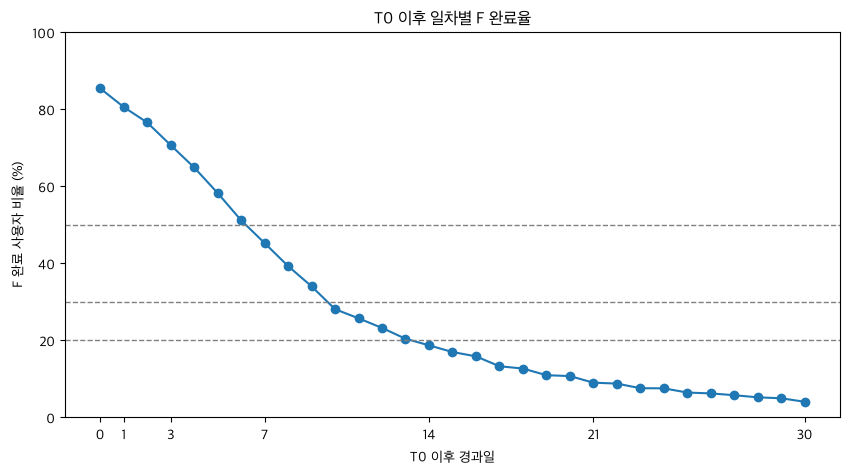

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    daily_retention_df["elapsed_day"],
    daily_retention_df["retention_rate"],
    marker="o"
)

for threshold in [50, 30, 20]:
    plt.axhline(
        threshold,
        color="gray",
        linestyle="--",
        linewidth=1
    )

plt.title("T0 이후 일차별 F 완료율")
plt.xlabel("T0 이후 경과일")
plt.ylabel("F 완료 사용자 비율 (%)")
plt.xticks([0, 1, 3, 7, 14, 21, 30])
plt.ylim(0, 100)
plt.show()

In [111]:
max_complete_week = int(
    (
        OBSERVATION_END_AT
        - retention_user_df["t0_at"].min()
    ).total_seconds()
    // (7 * 24 * 60 * 60)
)

weekly_rows = []

for week in range(1, max_complete_week + 1):
    start_day = (week - 1) * 7
    end_day = week * 7

    eligible_df = retention_user_df[
        retention_user_df["t0_at"]
        + pd.Timedelta(days=end_day)
        <= OBSERVATION_END_AT
    ]

    eligible_ids = set(eligible_df["user_id"])

    retained_ids = set(
        f_after_t0_df.loc[
            (f_after_t0_df["elapsed_day"] >= start_day)
            & (f_after_t0_df["elapsed_day"] < end_day)
            & f_after_t0_df["user_id"].isin(eligible_ids),
            "user_id"
        ]
    )

    denominator = len(eligible_ids)
    numerator = len(retained_ids)

    ci_low, ci_high = wilson_interval(
        numerator,
        denominator
    )

    weekly_rows.append({
        "week": week,
        "window": f"D{start_day}~D{end_day - 1}",
        "numerator": numerator,
        "denominator": denominator,
        "weekly_retention_rate": (
            numerator / denominator
            if denominator > 0
            else float("nan")
        ),
        "ci_95_low": ci_low,
        "ci_95_high": ci_high
    })

weekly_retention_df = pd.DataFrame(weekly_rows)

In [112]:
weekly_retention_df[
    [
        "weekly_retention_rate",
        "ci_95_low",
        "ci_95_high"
    ]
] = (
    weekly_retention_df[
        [
            "weekly_retention_rate",
            "ci_95_low",
            "ci_95_high"
        ]
    ] * 100
).round(2)

weekly_retention_df

,week,window,numerator,denominator,weekly_retention_rate,ci_95_low,ci_95_high
0,1,D0~D6,4800,5090,94.30,93.63,94.91
1,2,D7~D13,3418,5090,67.15,65.85,68.43
2,3,D14~D20,2090,5089,41.07,39.72,42.43
3,4,D21~D27,1244,5089,24.44,23.28,25.64
4,5,D28~D34,718,5089,14.11,13.18,15.09
5,6,D35~D41,354,5088,6.96,6.29,7.69
6,7,D42~D48,189,5088,3.71,3.23,4.27
7,8,D49~D55,140,5087,2.75,2.34,3.24
8,9,D56~D62,86,5086,1.69,1.37,2.08
9,10,D63~D69,115,5086,2.26,1.89,2.71


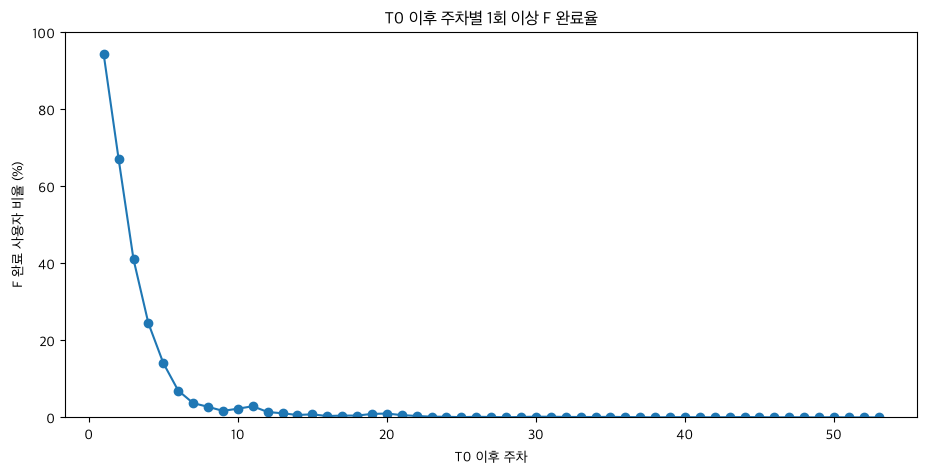

In [113]:
plt.figure(figsize=(11, 5))

plt.plot(
    weekly_retention_df["week"],
    weekly_retention_df["weekly_retention_rate"],
    marker="o"
)

plt.title("T0 이후 주차별 1회 이상 F 완료율")
plt.xlabel("T0 이후 주차")
plt.ylabel("F 완료 사용자 비율 (%)")
plt.ylim(0, 100)
plt.show()

- 1주차에는 대부분 F 경험
- 2~4주차에 급격히 감소
- 6주차 전후에는 한 자릿수
- 이후 거의 0%에 가까운 장기 활동
- D3 70.73%에서 D7 45.28%로 약 25.45%p 하락해, T0 이후 4~7일 구간이 가장 먼저 점검할 핵심 구간으로 보인다.

### 월별 T0 코호트 규모

In [114]:
monthly_t0_df = (
    retention_user_df
    .groupby("t0_month", as_index=False)
    .agg(
        t0_user_count=("user_id", "nunique"),
        school_count=("school_id", "nunique"),
        group_count=("group_id", "nunique"),
        first_t0_at=("t0_at", "min"),
        last_t0_at=("t0_at", "max")
    )
)

monthly_t0_df["user_share_pct"] = (
    monthly_t0_df["t0_user_count"]
    / retention_user_df["user_id"].nunique()
    * 100
).round(2)

monthly_t0_df = monthly_t0_df[
    [
        "t0_month",
        "t0_user_count",
        "user_share_pct",
        "school_count",
        "group_count",
        "first_t0_at",
        "last_t0_at"
    ]
]

display(monthly_t0_df)

,t0_month,t0_user_count,user_share_pct,school_count,group_count,first_t0_at,last_t0_at
0,2023-04,366,7.19,1,32,2023-04-28 03:43:18.503902+00:00,2023-04-30 23:05:11.234421+00:00
1,2023-05,4669,91.73,10,348,2023-05-01 03:45:13.061204+00:00,2023-05-31 13:24:51.581533+00:00
2,2023-06,35,0.69,9,31,2023-06-01 11:32:38.736985+00:00,2023-06-29 08:36:52.982230+00:00
3,2023-07,4,0.08,4,4,2023-07-06 14:14:30.805435+00:00,2023-07-25 07:14:51.718463+00:00
4,2023-08,2,0.04,2,2,2023-08-01 11:51:13.811964+00:00,2023-08-28 04:36:28.183437+00:00
5,2023-09,3,0.06,3,3,2023-09-13 16:06:38.453835+00:00,2023-09-23 08:52:16.138685+00:00
6,2023-10,1,0.02,1,1,2023-10-09 03:07:45.354455+00:00,2023-10-09 03:07:45.354455+00:00
7,2023-11,1,0.02,1,1,2023-11-18 15:12:55.132769+00:00,2023-11-18 15:12:55.132769+00:00
8,2023-12,2,0.04,2,2,2023-12-02 19:00:49.366020+00:00,2023-12-06 14:44:01.270373+00:00
9,2024-01,2,0.04,2,2,2024-01-13 14:04:12.733549+00:00,2024-01-28 12:04:22.494624+00:00


In [115]:
# 각 월의 학교 구성 확인
t0_month_school_df = pd.crosstab(
    retention_user_df["t0_month"],
    retention_user_df["school_id"]
).sort_index()

t0_month_school_df["전체"] = t0_month_school_df.sum(axis=1)

display(t0_month_school_df)

school_id,271,352,369,1478,1719,4426,4516,5372,5491,5520,전체
t0_month,,,,,,,,,,,
2023-04,366,0,0,0,0,0,0,0,0,0,366
2023-05,121,488,570,486,549,482,500,503,477,493,4669
2023-06,3,2,2,1,0,5,9,2,7,4,35
2023-07,0,0,1,0,1,0,0,0,1,1,4
2023-08,1,0,0,1,0,0,0,0,0,0,2
2023-09,1,1,0,0,0,0,1,0,0,0,3
2023-10,0,0,0,0,0,0,0,1,0,0,1
2023-11,0,0,0,0,0,0,0,0,1,0,1
2023-12,0,0,1,0,0,0,0,1,0,0,2


In [116]:
# 학교별 D0·D1·D3·D7·D14·D30
RETENTION_DAYS = [0, 1, 3, 7, 14, 30]

active_user_day_df = (
    f_after_t0_df.loc[
        f_after_t0_df["elapsed_day"].isin(RETENTION_DAYS),
        ["user_id", "elapsed_day"]
    ]
    .drop_duplicates()
)

school_retention_rows = []

for school_id, cohort in retention_user_df.groupby("school_id"):

    cohort = cohort[["user_id", "t0_at"]].drop_duplicates()

    row = {
        "school_id": school_id,
        "t0_users": cohort["user_id"].nunique()
    }

    for day in RETENTION_DAYS:

        eligible = cohort[
            cohort["t0_at"] + pd.Timedelta(days=day + 1)
            <= OBSERVATION_END_AT
        ]

        active_ids = active_user_day_df.loc[
            active_user_day_df["elapsed_day"] == day,
            "user_id"
        ]

        numerator = eligible["user_id"].isin(active_ids).sum()
        denominator = eligible["user_id"].nunique()

        row[f"D{day}"] = (
            round(numerator / denominator * 100, 2)
            if denominator > 0 else None
        )

        if day == 30:
            row["D30_eligible"] = denominator

    school_retention_rows.append(row)

school_retention_df = (
    pd.DataFrame(school_retention_rows)
    .sort_values("D7", ascending=False)
    .reset_index(drop=True)
)

display(school_retention_df)

,school_id,t0_users,D0,D1,D3,D7,D14,D30,D30_eligible
0,5520,500,87.20,82.20,78.80,62.00,31.20,8.40,500
1,4426,487,79.67,75.77,70.43,53.39,25.26,0.62,487
2,1478,488,76.02,80.53,66.19,50.00,24.80,4.71,488
3,5491,486,79.84,77.37,76.95,48.56,14.81,1.65,486
4,5372,507,83.43,81.46,72.19,45.96,14.79,1.18,507
5,271,492,88.01,79.67,68.90,45.73,18.70,9.55,492
6,1719,551,92.38,88.20,78.77,42.83,15.06,0.91,551
7,4516,510,84.90,76.47,70.39,41.96,22.55,6.27,510
8,369,578,90.14,82.87,68.69,35.29,12.80,5.37,577
9,352,491,91.24,80.45,55.19,29.12,8.55,1.83,491


- 4월 T0: 366명(7.19%), 전부 학교 271
- 5월 T0: 4,669명(91.73%), 10개 학교
- 6월 이후: 55명(1.08%)뿐
- 4~5월 합계가 전체의 98.92%
- 표본이 학교당 약 486~578명으로 비슷한데 D7 학교 간 격차가 최대 32.88%p이다
- 주 지표는 D7 Exact-day retention로 보려고한다.

# B: 어떤 초기 경험이 D7 유지와 연결되는가

## B-1 이용 강도: 초기 F 완료량·반복일수

In [137]:
# D7 전체 24시간을 관찰할 수 있는 사용자
d7_user_df = retention_user_df[
    retention_user_df["t0_at"] + pd.Timedelta(days=8)
    <= OBSERVATION_END_AT
].copy()

# 개인별 T0 이후 D7 구간에 F 완료가 있었던 사용자
d7_retained_ids = set(
    active_user_day_df.loc[
        active_user_day_df["elapsed_day"] == 7,
        "user_id"
    ]
)

d7_user_df["d7_retained"] = (
    d7_user_df["user_id"].isin(d7_retained_ids).astype(int)
)

print("D7 분석 대상:", len(d7_user_df))
print("D7 유지 사용자:", d7_user_df["d7_retained"].sum())
print(
    "D7 유지율:",
    round(d7_user_df["d7_retained"].mean() * 100, 2),
    "%"
)

D7 분석 대상: 5090
D7 유지 사용자: 2305
D7 유지율: 45.28 %


In [138]:
early_f_feature_df = (
    f_after_t0_df[
        f_after_t0_df["elapsed_day"].between(0, 2)
    ]
    .groupby("user_id", as_index=False)
    .agg(
        early_f_count=("f_at_proxy", "size"),
        early_active_days=("elapsed_day", "nunique"),
        first_f_at=("f_at_proxy", "min")
    )
)

d7_analysis_df = d7_user_df.merge(
    early_f_feature_df,
    on="user_id",
    how="left"
)

d7_analysis_df["early_f_count"] = (
    d7_analysis_df["early_f_count"].fillna(0).astype(int)
)

d7_analysis_df["early_active_days"] = (
    d7_analysis_df["early_active_days"].fillna(0).astype(int)
)

d7_analysis_df["first_f_delay_hour"] = (
    d7_analysis_df["first_f_at"] - d7_analysis_df["t0_at"]
).dt.total_seconds() / 3600

display(
    d7_analysis_df[
        [
            "early_f_count",
            "early_active_days",
            "first_f_delay_hour"
        ]
    ].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

,early_f_count,early_active_days,first_f_delay_hour
count,5090.000000,5090.000000,4673.000000
mean,13.463065,2.426916,5.176908
std,10.381025,0.955619,11.838441
min,0.000000,0.000000,0.003388
25%,5.000000,2.000000,0.044076
50%,12.000000,3.000000,0.130732
75%,20.000000,3.000000,2.910080
90%,28.000000,3.000000,19.048284
95%,33.000000,3.000000,32.032028
max,63.000000,3.000000,71.782846


- 초기 72시간 F 완료 없음: 5,090 - 4,673 = 417명(8.19%)
- F 완료 횟수 중앙값: 12회
- 초기 3일 모두 F 완료가 있었던 사용자가 절반 이상
- 첫 F 완료 중앙값: T0 이후 약 0.13시간, 즉 약 7.8분
- 다만 P90은 약 19시간, P95는 약 32시간이라 늦게 시작하는 사용자도 존재

In [139]:
d7_analysis_df["early_f_active_days"] = (
    d7_analysis_df["early_active_days"]
)

# 초기 완료량: 실제 분위수를 기준으로 구간화
d7_analysis_df["early_f_count_bin"] = pd.cut(
    d7_analysis_df["early_f_count"],
    bins=[-1, 0, 5, 12, 20, np.inf],
    labels=["0회", "1~5회", "6~12회", "13~20회", "21회 이상"]
)

retention_by_early_count_df = (
    d7_analysis_df
    .groupby("early_f_count_bin", observed=True)
    ["d7_retained"]
    .agg(
        user_count="size",
        d7_user_count="sum",
        d7_retention_rate="mean"
    )
    .reset_index()
)

retention_by_early_count_df["d7_retention_rate"] = (
    retention_by_early_count_df["d7_retention_rate"] * 100
).round(2)

display(retention_by_early_count_df)

,early_f_count_bin,user_count,d7_user_count,d7_retention_rate
0,0회,417,104,24.94
1,1~5회,891,235,26.37
2,6~12회,1389,551,39.67
3,13~20회,1207,628,52.03
4,21회 이상,1186,787,66.36


In [140]:
# 초기 72시간 중 F 완료가 있었던 일수
retention_by_early_days_df = (
    d7_analysis_df
    .groupby("early_f_active_days")
    ["d7_retained"]
    .agg(
        user_count="size",
        d7_user_count="sum",
        d7_retention_rate="mean"
    )
    .reset_index()
)

retention_by_early_days_df["d7_retention_rate"] = (
    retention_by_early_days_df["d7_retention_rate"] * 100
).round(2)

display(retention_by_early_days_df)

,early_f_active_days,user_count,d7_user_count,d7_retention_rate
0,0,417,104,24.94
1,1,450,108,24.00
2,2,766,264,34.46
3,3,3457,1829,52.91


In [141]:
# 첫 F 완료까지 걸린 시간
delay_bin = pd.cut(
    d7_analysis_df["first_f_delay_hour"],
    bins=[0, 1 / 6, 3, 24, 72],
    labels=[
        "10분 이내",
        "10분~3시간",
        "3~24시간",
        "24~72시간"
    ],
    include_lowest=True
)

d7_analysis_df["first_f_delay_bin"] = (
    delay_bin.astype("string").fillna("초기 F 없음")
)

delay_order = [
    "초기 F 없음",
    "10분 이내",
    "10분~3시간",
    "3~24시간",
    "24~72시간"
]

d7_analysis_df["first_f_delay_bin"] = pd.Categorical(
    d7_analysis_df["first_f_delay_bin"],
    categories=delay_order,
    ordered=True
)

retention_by_first_f_delay_df = (
    d7_analysis_df
    .groupby("first_f_delay_bin", observed=True)
    ["d7_retained"]
    .agg(
        user_count="size",
        d7_user_count="sum",
        d7_retention_rate="mean"
    )
    .reset_index()
)

retention_by_first_f_delay_df["d7_retention_rate"] = (
    retention_by_first_f_delay_df["d7_retention_rate"] * 100
).round(2)

display(retention_by_first_f_delay_df)

,first_f_delay_bin,user_count,d7_user_count,d7_retention_rate
0,초기 F 없음,417,104,24.94
1,10분 이내,2471,1096,44.35
2,10분~3시간,1043,516,49.47
3,3~24시간,836,391,46.77
4,24~72시간,323,198,61.30


In [142]:
volume_days_df = (
    d7_analysis_df
    .groupby(
        ["early_f_active_days", "early_f_count_bin"],
        observed=True
    )
    ["d7_retained"]
    .agg(
        user_count="size",
        d7_user_count="sum",
        d7_retention_rate="mean"
    )
    .reset_index()
)

volume_days_df["d7_retention_rate"] = (
    volume_days_df["d7_retention_rate"] * 100
).round(2)

# 각 조합의 표본 수
display(
    volume_days_df.pivot(
        index="early_f_active_days",
        columns="early_f_count_bin",
        values="user_count"
    )
)

# 각 조합의 D7 유지율
display(
    volume_days_df.pivot(
        index="early_f_active_days",
        columns="early_f_count_bin",
        values="d7_retention_rate"
    )
)

early_f_count_bin,0회,1~5회,6~12회,13~20회,21회 이상
early_f_active_days,,,,,
0,417.0,NaN,NaN,NaN,NaN
1,NaN,408.0,40.0,2.0,NaN
2,NaN,343.0,339.0,73.0,11.0
3,NaN,140.0,1010.0,1132.0,1175.0


early_f_count_bin,0회,1~5회,6~12회,13~20회,21회 이상
early_f_active_days,,,,,
0,24.94,NaN,NaN,NaN,NaN
1,NaN,21.81,45.00,50.00,NaN
2,NaN,29.45,35.99,47.95,54.55
3,NaN,32.14,40.69,52.30,66.47


In [143]:
delay_profile_df = (
    d7_analysis_df
    .groupby("first_f_delay_bin", observed=True)
    .agg(
        user_count=("user_id", "nunique"),
        avg_early_f_count=("early_f_count", "mean"),
        median_early_f_count=("early_f_count", "median"),
        avg_early_f_active_days=("early_f_active_days", "mean"),
        three_day_user_rate=(
            "early_f_active_days",
            lambda x: (x == 3).mean() * 100
        ),
        d7_retention_rate=(
            "d7_retained",
            lambda x: x.mean() * 100
        )
    )
    .reset_index()
)

for col in [
    "avg_early_f_count",
    "avg_early_f_active_days",
    "three_day_user_rate",
    "d7_retention_rate"
]:
    delay_profile_df[col] = delay_profile_df[col].round(2)

display(delay_profile_df)

,first_f_delay_bin,user_count,avg_early_f_count,median_early_f_count,avg_early_f_active_days,three_day_user_rate,d7_retention_rate
0,초기 F 없음,417,0.00,0.0,0.00,0.00,24.94
1,10분 이내,2471,15.39,14.0,2.69,77.82,44.35
2,10분~3시간,1043,16.79,15.0,2.78,82.36,49.47
3,3~24시간,836,13.09,11.0,2.75,80.74,46.77
4,24~72시간,323,6.33,5.0,1.58,0.00,61.30


### 학교와 T0 시점이 같다고 가정했을 때도 초기 이용량·반복일수 차이가 남는지 확인

In [144]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

adjusted_df = d7_analysis_df[
    d7_analysis_df["t0_month"].isin(["2023-04", "2023-05"])
].copy()

adjusted_df["t0_week"] = (
    adjusted_df["t0_at"]
    .dt.tz_convert(None)
    .dt.to_period("W-SUN")
    .astype(str)
)

adjusted_df["early_f_any"] = (
    adjusted_df["early_f_count"] > 0
).astype(int)

# 질문셋 5개 증가 단위로 해석
adjusted_df["early_f_count_5"] = (
    adjusted_df["early_f_count"] / 5
)

print("전체 기술통계 사용자:", len(d7_analysis_df))
print("4~5월 보정모델 사용자:", len(adjusted_df))
print(
    "보정모델 포함률:",
    round(len(adjusted_df) / len(d7_analysis_df) * 100, 2),
    "%"
)
print("학급 수:", adjusted_df["group_id"].nunique())
print("T0 주차 수:", adjusted_df["t0_week"].nunique())

전체 기술통계 사용자: 5090
4~5월 보정모델 사용자: 5035
보정모델 포함률: 98.92 %
학급 수: 352
T0 주차 수: 6


In [145]:
# statsmodels 호환 자료형으로 변환
for col in [
    "d7_retained",
    "early_f_any",
    "early_f_count",
    "early_f_active_days",
    "group_id"
]:
    adjusted_df[col] = (
        pd.to_numeric(adjusted_df[col], errors="raise")
        .astype("int64")
    )

adjusted_df["early_f_count_5"] = (
    adjusted_df["early_f_count"].astype("float64") / 5
)

# 범주형 변수는 일반 문자열 object로 변환
adjusted_df["school_id_cat"] = (
    adjusted_df["school_id"].astype(str).astype(object)
)

adjusted_df["t0_week_cat"] = (
    adjusted_df["t0_week"].astype(str).astype(object)
)

print(adjusted_df[
    [
        "d7_retained",
        "early_f_any",
        "early_f_count_5",
        "early_f_active_days",
        "school_id_cat",
        "t0_week_cat",
        "group_id"
    ]
].dtypes)

d7_retained              int64
early_f_any              int64
early_f_count_5        float64
early_f_active_days      int64
school_id_cat           object
t0_week_cat             object
group_id                 int64
dtype: object


In [146]:
activation_model = smf.logit(
    formula="""
        d7_retained
        ~ early_f_any
        + C(school_id_cat)
        + C(t0_week_cat)
    """,
    data=adjusted_df
).fit(
    disp=False,
    cov_type="cluster",
    cov_kwds={"groups": adjusted_df["group_id"]}
)

In [147]:
positive_df = adjusted_df[
    adjusted_df["early_f_any"] == 1
].copy()

depth_model = smf.logit(
    formula="""
        d7_retained
        ~ early_f_count_5
        + C(early_f_active_days)
        + C(school_id_cat)
        + C(t0_week_cat)
    """,
    data=positive_df
).fit(
    disp=False,
    cov_type="cluster",
    cov_kwds={"groups": positive_df["group_id"]}
)

In [148]:
def extract_or_table(model, keywords):

    ci = model.conf_int()

    result = pd.DataFrame({
        "variable": model.params.index,
        "odds_ratio": np.exp(model.params.values),
        "ci_95_low": np.exp(ci[0].values),
        "ci_95_high": np.exp(ci[1].values),
        "p_value": model.pvalues.values
    })

    result = result[
        result["variable"].apply(
            lambda x: any(keyword in x for keyword in keywords)
        )
    ].copy()

    for col in ["odds_ratio", "ci_95_low", "ci_95_high"]:
        result[col] = result[col].round(3)

    result["p_value"] = result["p_value"].round(4)

    return result.reset_index(drop=True)

In [149]:
activation_or_df = extract_or_table(
    activation_model,
    keywords=["early_f_any"]
)

depth_or_df = extract_or_table(
    depth_model,
    keywords=[
        "early_f_count_5",
        "early_f_active_days"
    ]
)

display(activation_or_df)
display(depth_or_df)

,variable,odds_ratio,ci_95_low,ci_95_high,p_value
0,early_f_any,2.652,1.962,3.585,0.0


,variable,odds_ratio,ci_95_low,ci_95_high,p_value
0,C(early_f_active_days)[T.2],1.168,0.882,1.546,0.2796
1,C(early_f_active_days)[T.3],1.439,1.091,1.898,0.0101
2,early_f_count_5,1.369,1.308,1.432,0.0000


- 학교와 T0 주차의 차이를 고려한 후에도 초기 72시간의 질문셋 완료량은 D7 유지와 유의한 양의 관계를 보였다. 
- 초기 질문셋 완료 경험자에서 완료량이 5개 증가할 때 D7 유지 오즈는 36.9% 증가했으며, 동일한 완료량을 고려한 경우 3일 모두 질문셋을 완료한 사용자는 1일만 완료한 사용자보다 D7 유지 오즈가 43.9% 높았다. 반면 2일 활동은 1일 활동과 유의한 차이가 확인되지 않았다.
- 따라서 한 번 체험시키는 것만으로는 부족하고, 초기 3일 동안 충분한 질문을 반복 완료하도록 만드는 경험이 중요하다

## B-2 사회적 반응: 받은 투표·고유 투표자·상호 투표·활성 동급생

In [150]:
EARLY_SOCIAL_SQL = """
WITH target_users AS (

    SELECT
        CAST(user_id AS INT64) AS user_id,
        signup_date AS signup_at,
        CAST(group_id AS INT64) AS group_id,
        CAST(school_id AS INT64) AS school_id

    FROM `sns-analysis-prj.sns_analysis.stg_acquisition_user`

    WHERE school_id IN (
        1719, 369, 5372, 4516, 5520,
        4426, 271, 1478, 5491, 352
    )

),

school_ordered AS (

    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY school_id
            ORDER BY signup_at, user_id
        ) AS school_signup_order

    FROM target_users

),

school_threshold AS (

    SELECT
        school_id,
        MIN(
            IF(
                school_signup_order = 40,
                signup_at,
                NULL
            )
        ) AS school_40_at

    FROM school_ordered
    GROUP BY school_id

),

user_t0 AS (

    SELECT
        u.user_id,
        u.group_id,
        u.school_id,
        u.signup_at,
        s.school_40_at,
        GREATEST(
            u.signup_at,
            s.school_40_at
        ) AS t0_at

    FROM target_users u

    LEFT JOIN school_threshold s
        ON u.school_id = s.school_id

),

vote_base AS (

    SELECT
        SAFE_CAST(user_id AS INT64) AS voter_id,
        SAFE_CAST(chosen_user_id AS INT64) AS receiver_id,
        created_at AS vote_at

    FROM `sns-analysis-prj.sns_analysis.accounts_userquestionrecord`

    WHERE chosen_user_id IS NOT NULL
  AND SAFE_CAST(user_id AS INT64)
      != SAFE_CAST(chosen_user_id AS INT64)

),

sent_summary AS (

    SELECT
        u.user_id,
        COUNT(*) AS early_sent_vote_count,
        COUNT(DISTINCT v.receiver_id)
            AS early_sent_unique_receiver_count

    FROM user_t0 u

    JOIN vote_base v
        ON u.user_id = v.voter_id
       AND v.vote_at >= u.t0_at
       AND v.vote_at < TIMESTAMP_ADD(
           u.t0_at,
           INTERVAL 72 HOUR
       )

    GROUP BY u.user_id

),

received_summary AS (

    SELECT
        u.user_id,
        COUNT(*) AS early_received_vote_count,
        COUNT(DISTINCT v.voter_id)
            AS early_received_unique_voter_count

    FROM user_t0 u

    JOIN vote_base v
        ON u.user_id = v.receiver_id
       AND v.vote_at >= u.t0_at
       AND v.vote_at < TIMESTAMP_ADD(
           u.t0_at,
           INTERVAL 72 HOUR
       )

    GROUP BY u.user_id

),

sent_pairs AS (

    SELECT DISTINCT
        u.user_id,
        v.receiver_id AS partner_id

    FROM user_t0 u

    JOIN vote_base v
        ON u.user_id = v.voter_id
       AND v.vote_at >= u.t0_at
       AND v.vote_at < TIMESTAMP_ADD(
           u.t0_at,
           INTERVAL 72 HOUR
       )

),

received_pairs AS (

    SELECT DISTINCT
        u.user_id,
        v.voter_id AS partner_id

    FROM user_t0 u

    JOIN vote_base v
        ON u.user_id = v.receiver_id
       AND v.vote_at >= u.t0_at
       AND v.vote_at < TIMESTAMP_ADD(
           u.t0_at,
           INTERVAL 72 HOUR
       )

),

reciprocal_summary AS (

    SELECT
        s.user_id,
        COUNT(*) AS early_reciprocal_partner_count

    FROM sent_pairs s

    INNER JOIN received_pairs r
        ON s.user_id = r.user_id
       AND s.partner_id = r.partner_id

    GROUP BY s.user_id

),

active_classmate_summary AS (

    SELECT
        focal.user_id,
        COUNT(DISTINCT peer.user_id)
            AS early_active_classmate_count

    FROM user_t0 focal

    JOIN user_t0 peer
        ON focal.group_id = peer.group_id
       AND focal.user_id != peer.user_id

    JOIN vote_base v
        ON peer.user_id = v.voter_id
       AND v.vote_at >= focal.t0_at
       AND v.vote_at < TIMESTAMP_ADD(
           focal.t0_at,
           INTERVAL 72 HOUR
       )

    GROUP BY focal.user_id

)

SELECT
    u.user_id,

    COALESCE(
        s.early_sent_vote_count,
        0
    ) AS early_sent_vote_count,

    COALESCE(
        s.early_sent_unique_receiver_count,
        0
    ) AS early_sent_unique_receiver_count,

    COALESCE(
        r.early_received_vote_count,
        0
    ) AS early_received_vote_count,

    COALESCE(
        r.early_received_unique_voter_count,
        0
    ) AS early_received_unique_voter_count,

    COALESCE(
        rp.early_reciprocal_partner_count,
        0
    ) AS early_reciprocal_partner_count,

    COALESCE(
        ac.early_active_classmate_count,
        0
    ) AS early_active_classmate_count

FROM user_t0 u

LEFT JOIN sent_summary s
    ON u.user_id = s.user_id

LEFT JOIN received_summary r
    ON u.user_id = r.user_id

LEFT JOIN reciprocal_summary rp
    ON u.user_id = rp.user_id

LEFT JOIN active_classmate_summary ac
    ON u.user_id = ac.user_id

ORDER BY u.user_id
"""

In [151]:
dry_config = bigquery.QueryJobConfig(
    dry_run=True,
    use_query_cache=False
)

dry_job = client.query(
    EARLY_SOCIAL_SQL,
    job_config=dry_config,
    location="asia-northeast3"
)

early_social_df = (
    client.query(
        EARLY_SOCIAL_SQL,
        job_config=query_config,
        location="asia-northeast3"
    )
    .to_dataframe(
        create_bqstorage_client=False
    )
)

In [152]:
social_cols = [
    "early_sent_vote_count",
    "early_sent_unique_receiver_count",
    "early_received_vote_count",
    "early_received_unique_voter_count",
    "early_reciprocal_partner_count",
    "early_active_classmate_count"
]

print("행 수:", len(early_social_df))
print(
    "user_id 중복:",
    early_social_df["user_id"].duplicated().sum()
)
print(
    "결측치:",
    early_social_df[social_cols].isna().sum().sum()
)

display(
    early_social_df[social_cols].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

행 수: 5090
user_id 중복: 0
결측치: 0


,early_sent_vote_count,early_sent_unique_receiver_count,early_received_vote_count,early_received_unique_voter_count,early_reciprocal_partner_count,early_active_classmate_count
count,5090.0,5090.0,5090.0,5090.0,5090.0,5090.0
mean,105.132613,24.640864,85.031631,20.558546,13.87446,12.099411
std,89.892121,17.00065,72.655722,14.861363,10.788311,5.206932
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,34.0,12.0,31.0,10.0,5.0,9.0
50%,86.0,23.0,69.0,18.0,12.0,12.0
75%,156.0,35.0,120.0,28.0,20.0,16.0
90%,233.0,47.0,184.0,40.0,28.1,18.0
95%,281.0,55.0,224.0,49.0,34.0,20.0
max,533.0,146.0,600.0,116.0,70.0,32.0


In [153]:
# D7 분석 데이터와 초기 사회적 지표 결합
b_analysis_df = (
    d7_analysis_df
    .merge(
        early_social_df,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

# 결합 결과 검증
b_analysis_check = pd.Series({
    "행 수": len(b_analysis_df),
    "고유 사용자 수": b_analysis_df["user_id"].nunique(),
    "user_id 중복": b_analysis_df["user_id"].duplicated().sum(),
    "사회적 지표 결측": (
        b_analysis_df[social_cols]
        .isna()
        .sum()
        .sum()
    )
})

b_analysis_check

행 수           5090
고유 사용자 수      5090
user_id 중복       0
사회적 지표 결측        0
dtype: int64

In [154]:
b_corr_cols = [
    "early_f_count",
    "early_sent_vote_count",
    "early_sent_unique_receiver_count",
    "early_received_vote_count",
    "early_received_unique_voter_count",
    "early_reciprocal_partner_count",
    "early_active_classmate_count",
    "d7_retained"
]

display(
    b_analysis_df[b_corr_cols]
    .corr(method="spearman")
    .round(2)
)

,early_f_count,early_sent_vote_count,early_sent_unique_receiver_count,early_received_vote_count,early_received_unique_voter_count,early_reciprocal_partner_count,early_active_classmate_count,d7_retained
early_f_count,1.00,0.96,0.77,0.56,0.51,0.72,0.30,0.30
early_sent_vote_count,0.96,1.00,0.83,0.59,0.55,0.77,0.31,0.28
early_sent_unique_receiver_count,0.77,0.83,1.00,0.69,0.75,0.89,0.32,0.20
early_received_vote_count,0.56,0.59,0.69,1.00,0.91,0.86,0.34,0.12
early_received_unique_voter_count,0.51,0.55,0.75,0.91,1.00,0.89,0.33,0.11
early_reciprocal_partner_count,0.72,0.77,0.89,0.86,0.89,1.00,0.33,0.19
early_active_classmate_count,0.30,0.31,0.32,0.34,0.33,0.33,1.00,0.01
d7_retained,0.30,0.28,0.20,0.12,0.11,0.19,0.01,1.00


### F활동량 통제 후 사회적 지표 확인

In [179]:
b_model_df = b_analysis_df.copy()

# statsmodels가 pandas nullable Int64를 처리하지 못하는 문제 방지
numeric_cols = [
    "d7_retained",
    "early_f_count",
    "early_f_active_days",
    "early_sent_unique_receiver_count",
    "early_received_unique_voter_count",
    "early_reciprocal_partner_count",
    "early_active_classmate_count",
]

for col in numeric_cols:
    b_model_df[col] = pd.to_numeric(
        b_model_df[col],
        errors="coerce"
    ).astype("float64")

# 초기 활성화 통제변수
b_model_df["early_f_any"] = (
    b_model_df["early_f_count"] > 0
).astype("int64")

b_model_df["early_f_count_5"] = (
    b_model_df["early_f_count"] / 5
).astype("float64")

b_model_df["early_f_3day"] = (
    b_model_df["early_f_active_days"] == 3
).astype("int64")

# 사회적 지표: 1명 증가당 OR로 해석
social_features = {
    "발신 고유 상대 +1명":
        "early_sent_unique_receiver_count",
    "수신 고유 투표자 +1명":
        "early_received_unique_voter_count",
    "상호작용 상대 +1명":
        "early_reciprocal_partner_count",
    "활성 학급원 +1명":
        "early_active_classmate_count",
}

# 학교·T0 주차·학급 클러스터
b_model_df["school_id_cat"] = (
    b_model_df["school_id"].astype(str).astype(object)
)

b_model_df["t0_week_cat"] = (
    b_model_df["t0_at"]
    .dt.strftime("%G-W%V")
    .astype(object)
)

# 학교가 다르면 같은 group_id라도 별도 학급으로 처리
b_model_df["cluster_id"] = (
    b_model_df["school_id"].astype(str)
    + "_"
    + b_model_df["group_id"].astype(str)
)

In [156]:
social_model_rows = []
social_models = {}

base_formula = """
    d7_retained
    ~ early_f_any
    + early_f_count_5
    + early_f_3day
    + {social_variable}
    + C(school_id_cat)
    + C(t0_week_cat)
"""

for label, original_col in social_features.items():

    # 원래 변수를 그대로 사용 → 1명 증가당 OR
    model_col = original_col

    model = smf.logit(
        formula=base_formula.format(
            social_variable=model_col
        ),
        data=b_model_df
    ).fit(
        disp=False,
        cov_type="cluster",
        cov_kwds={
            "groups": b_model_df["cluster_id"]
        }
    )

    social_models[original_col] = model

    ci_low, ci_high = model.conf_int().loc[model_col]

    social_model_rows.append({
        "variable": label,
        "odds_ratio": np.exp(model.params[model_col]),
        "ci_95_low": np.exp(ci_low),
        "ci_95_high": np.exp(ci_high),
        "p_value": model.pvalues[model_col],
        "n": int(model.nobs),
    })

social_model_result = pd.DataFrame(social_model_rows)

social_model_result[
    ["odds_ratio", "ci_95_low", "ci_95_high"]
] = social_model_result[
    ["odds_ratio", "ci_95_low", "ci_95_high"]
].round(3)

social_model_result["p_value"] = (
    social_model_result["p_value"].round(4)
)

social_model_result

/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,variable,odds_ratio,ci_95_low,ci_95_high,p_value,n
0,발신 고유 상대 +1명,0.993,0.988,0.999,0.0200,5090
1,수신 고유 투표자 +1명,0.987,0.982,0.993,0.0000,5090
2,상호작용 상대 +1명,0.985,0.976,0.993,0.0003,5090
3,활성 학급원 +1명,0.962,0.946,0.978,0.0000,5090


- 초기 3일의 개인 F 수행량과 반복 활동은 D7 유지와 뚜렷한 연관성을 보였으나, 이를 통제한 이후 발신·수신·상호작용 상대 수와 활성 학급원 수에서는 추가적인 양의 유지 효과가 확인되지 않았다. 
- 따라서 초기 유지에는 사회적 접촉 범위보다 개인의 초기 참여 강도와 반복성이 더 직접적으로 관련된 것으로 해석된다.

#### 사회적 지표가 정말 음의 관계인지, 개인 활동량을 통제하면서 부호가 뒤집힌 것인지 확인

In [157]:
# 분석 대상 내 동일 학급 사용자 수
b_model_df["class_user_count"] = (
    b_model_df
    .groupby(["school_id", "group_id"])["user_id"]
    .transform("nunique")
    .astype("float64")
)

# 본인을 제외한 학급원 수
b_model_df["classmate_pool"] = (
    b_model_df["class_user_count"] - 1
).clip(lower=0)

In [158]:
comparison_rows = []
comparison_models = {}

formula_dict = {
    "① 학교·주차·학급규모 보정": """
        d7_retained
        ~ {social_variable}
        + classmate_pool
        + C(school_id_cat)
        + C(t0_week_cat)
    """,

    "② 개인 초기활동 추가 보정": """
        d7_retained
        ~ {social_variable}
        + early_f_any
        + early_f_count_5
        + early_f_3day
        + classmate_pool
        + C(school_id_cat)
        + C(t0_week_cat)
    """
}

for label, social_col in social_features.items():

    for model_type, formula in formula_dict.items():

        model = smf.logit(
            formula=formula.format(
                social_variable=social_col
            ),
            data=b_model_df
        ).fit(
            disp=False,
            cov_type="cluster",
            cov_kwds={
                "groups": b_model_df["cluster_id"]
            }
        )

        comparison_models[(social_col, model_type)] = model

        ci_low, ci_high = model.conf_int().loc[social_col]

        comparison_rows.append({
            "variable": label,
            "model": model_type,
            "odds_ratio": np.exp(model.params[social_col]),
            "ci_95_low": np.exp(ci_low),
            "ci_95_high": np.exp(ci_high),
            "p_value": model.pvalues[social_col],
            "n": int(model.nobs),
        })

social_model_comparison = pd.DataFrame(comparison_rows)

social_model_comparison[
    ["odds_ratio", "ci_95_low", "ci_95_high"]
] = social_model_comparison[
    ["odds_ratio", "ci_95_low", "ci_95_high"]
].round(3)

social_model_comparison["p_value"] = (
    social_model_comparison["p_value"].round(4)
)

social_model_comparison

/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_

,variable,model,odds_ratio,ci_95_low,ci_95_high,p_value,n
0,발신 고유 상대 +1명,① 학교·주차·학급규모 보정,1.025,1.020,1.029,0.0000,5090
1,발신 고유 상대 +1명,② 개인 초기활동 추가 보정,0.993,0.987,0.998,0.0112,5090
2,수신 고유 투표자 +1명,① 학교·주차·학급규모 보정,1.007,1.002,1.012,0.0048,5090
3,수신 고유 투표자 +1명,② 개인 초기활동 추가 보정,0.987,0.981,0.992,0.0000,5090
4,상호작용 상대 +1명,① 학교·주차·학급규모 보정,1.032,1.025,1.039,0.0000,5090
5,상호작용 상대 +1명,② 개인 초기활동 추가 보정,0.984,0.976,0.992,0.0002,5090
6,활성 학급원 +1명,① 학교·주차·학급규모 보정,0.939,0.917,0.962,0.0000,5090
7,활성 학급원 +1명,② 개인 초기활동 추가 보정,0.870,0.847,0.894,0.0000,5090


- 초기 사회적 접촉 범위가 넓은 사용자는 표면적으로 D7 유지율이 높았지만, 개인의 초기 F 수행량과 반복 활동을 통제하자 양의 관계가 사라졌다. 
- 초기 유지에는 접촉한 사람 수보다 개인이 서비스를 얼마나 많이, 반복적으로 사용했는지가 더 직접적으로 관련됐다.

### 넓고 얕은 관계보다 소수 상대와의 반복적인 상호작용이 중요한가?

In [159]:
classmate_validation = pd.Series({
    "활성 학급원 > 가능한 학급원": (
        b_model_df["early_active_classmate_count"]
        > b_model_df["classmate_pool"]
    ).sum(),

    "가능한 학급원 0명": (
        b_model_df["classmate_pool"] == 0
    ).sum(),

    "활성 학급원 평균": (
        b_model_df["early_active_classmate_count"].mean()
    ),

    "가능한 학급원 평균": (
        b_model_df["classmate_pool"].mean()
    ),

    "두 변수 상관계수": (
        b_model_df[
            ["early_active_classmate_count", "classmate_pool"]
        ].corr().iloc[0, 1]
    )
})

classmate_validation

활성 학급원 > 가능한 학급원     0.000000
가능한 학급원 0명           9.000000
활성 학급원 평균           12.099411
가능한 학급원 평균          16.037328
두 변수 상관계수            0.728357
dtype: float64

In [160]:
peer_model_df = b_model_df[
    b_model_df["classmate_pool"] > 0
].copy()

peer_model_df["active_classmate_rate"] = (
    peer_model_df["early_active_classmate_count"]
    / peer_model_df["classmate_pool"]
)

# 비율 10%p 증가당 OR로 해석
peer_model_df["active_classmate_rate_10pp"] = (
    peer_model_df["active_classmate_rate"] * 10
)

peer_model_df[
    [
        "active_classmate_rate",
        "active_classmate_rate_10pp"
    ]
].describe()

,active_classmate_rate,active_classmate_rate_10pp
count,5081.000000,5081.000000
mean,0.750322,7.503221
std,0.222948,2.229479
min,0.000000,0.000000
25%,0.666667,6.666667
50%,0.812500,8.125000
75%,0.909091,9.090909
max,1.000000,10.000000


- 상관이 0.728이면 학급이 클수록 활성 학급원 수도 많아지는 영향이 상당히 섞여 있는 것으로 보여진다.
- 따라서 활성 학급원 비율로 다시 봐야 할 것 같다.

#### 비율 기준 회귀분석

In [161]:
peer_formula_dict = {
    "① 학교·주차·학급규모 보정": """
        d7_retained
        ~ active_classmate_rate_10pp
        + classmate_pool
        + C(school_id_cat)
        + C(t0_week_cat)
    """,

    "② 개인 초기활동 추가 보정": """
        d7_retained
        ~ active_classmate_rate_10pp
        + early_f_any
        + early_f_count_5
        + early_f_3day
        + classmate_pool
        + C(school_id_cat)
        + C(t0_week_cat)
    """
}

peer_rows = []

for model_name, formula in peer_formula_dict.items():

    model = smf.logit(
        formula=formula,
        data=peer_model_df
    ).fit(
        disp=False,
        cov_type="cluster",
        cov_kwds={
            "groups": peer_model_df["cluster_id"]
        }
    )

    variable = "active_classmate_rate_10pp"
    ci_low, ci_high = model.conf_int().loc[variable]

    peer_rows.append({
        "model": model_name,
        "odds_ratio": np.exp(model.params[variable]),
        "ci_95_low": np.exp(ci_low),
        "ci_95_high": np.exp(ci_high),
        "p_value": model.pvalues[variable],
        "n": int(model.nobs),
    })

peer_model_result = pd.DataFrame(peer_rows)

peer_model_result[
    ["odds_ratio", "ci_95_low", "ci_95_high"]
] = peer_model_result[
    ["odds_ratio", "ci_95_low", "ci_95_high"]
].round(3)

peer_model_result["p_value"] = (
    peer_model_result["p_value"].round(4)
)


peer_model_result

/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,model,odds_ratio,ci_95_low,ci_95_high,p_value,n
0,① 학교·주차·학급규모 보정,0.909,0.877,0.942,0.0,5081
1,② 개인 초기활동 추가 보정,0.799,0.768,0.831,0.0,5081


- 초기 학급 활성도는 D7 유지에 긍정적인 신호를 보이지 않았다. 
- 개인의 초기 이용량을 통제한 이후에도 활성 학급원 비율은 D7 유지와 음의 관계를 보였으며, 이는 학급 단위의 동시 활성화가 장기 유지보다 단기적인 이용 집중에 가까웠을 가능성을 시사한다. 다만 인과관계로 해석할 수는 없다.

### 반복깊이 중요도 확인

In [162]:
depth_df = b_model_df.copy()

# 한 상대에게 평균 몇 번 투표했는지
depth_df["sent_votes_per_receiver"] = np.where(
    depth_df["early_sent_unique_receiver_count"] > 0,
    depth_df["early_sent_vote_count"]
    / depth_df["early_sent_unique_receiver_count"],
    np.nan
)

# 한 투표자에게 평균 몇 표를 받았는지
depth_df["received_votes_per_voter"] = np.where(
    depth_df["early_received_unique_voter_count"] > 0,
    depth_df["early_received_vote_count"]
    / depth_df["early_received_unique_voter_count"],
    np.nan
)

# 발신 또는 수신으로 연결된 전체 고유 상대 수
depth_df["early_connected_partner_count"] = (
    depth_df["early_sent_unique_receiver_count"]
    + depth_df["early_received_unique_voter_count"]
    - depth_df["early_reciprocal_partner_count"]
)

# 연결 상대 중 서로 투표한 상대의 비율
depth_df["reciprocal_partner_rate"] = np.where(
    depth_df["early_connected_partner_count"] > 0,
    depth_df["early_reciprocal_partner_count"]
    / depth_df["early_connected_partner_count"],
    np.nan
)

depth_df[
    [
        "sent_votes_per_receiver",
        "received_votes_per_voter",
        "reciprocal_partner_rate"
    ]
].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
)

,sent_votes_per_receiver,received_votes_per_voter,reciprocal_partner_rate
count,4664.000000,4885.000000,4937.000000
mean,4.289698,3.950424,0.406875
std,4.433341,1.705150,0.197516
min,1.000000,1.000000,0.000000
25%,2.400000,2.789474,0.294118
50%,3.515587,3.714286,0.428571
75%,5.207804,4.800000,0.545455
90%,7.577521,6.028438,0.640000
95%,9.356513,7.000000,0.694444
max,174.000000,20.000000,1.000000


#### 임의 구간이나 이상치 절단 대신, 반복 강도는 log2로 바꿔서 반복 강도가 2배가 될 때로 비교

In [163]:
# 반복 강도 2배 증가 단위
depth_df["log2_sent_depth"] = np.log2(
    depth_df["sent_votes_per_receiver"]
)

depth_df["log2_received_depth"] = np.log2(
    depth_df["received_votes_per_voter"]
)

# 상호작용 상대 비율 10%p 증가 단위
depth_df["reciprocal_rate_10pp"] = (
    depth_df["reciprocal_partner_rate"] * 10
)

In [164]:
depth_features = {
    "발신 반복 강도 2배":
        "log2_sent_depth",
    "수신 반복 강도 2배":
        "log2_received_depth",
    "쌍방 상호작용 비율 +10%p":
        "reciprocal_rate_10pp",
}

depth_model_rows = []
depth_models = {}

for label, feature in depth_features.items():

    model_df = depth_df.dropna(
        subset=[feature]
    ).copy()

    # 해당 표본에서 early_f_any에 변화가 있을 때만 포함
    activity_controls = [
        "early_f_count_5",
        "early_f_3day"
    ]

    if model_df["early_f_any"].nunique() > 1:
        activity_controls.insert(0, "early_f_any")

    formula = f"""
        d7_retained
        ~ {feature}
        + {" + ".join(activity_controls)}
        + classmate_pool
        + C(school_id_cat)
        + C(t0_week_cat)
    """

    model = smf.logit(
        formula=formula,
        data=model_df
    ).fit(
        disp=False,
        cov_type="cluster",
        cov_kwds={
            "groups": model_df["cluster_id"]
        }
    )

    depth_models[feature] = model

    ci_low, ci_high = model.conf_int().loc[feature]

    depth_model_rows.append({
        "variable": label,
        "odds_ratio": np.exp(model.params[feature]),
        "ci_95_low": np.exp(ci_low),
        "ci_95_high": np.exp(ci_high),
        "p_value": model.pvalues[feature],
        "n": int(model.nobs),
    })

depth_model_result = pd.DataFrame(depth_model_rows)

depth_model_result[
    ["odds_ratio", "ci_95_low", "ci_95_high"]
] = depth_model_result[
    ["odds_ratio", "ci_95_low", "ci_95_high"]
].round(3)

depth_model_result["p_value"] = (
    depth_model_result["p_value"].round(4)
)

depth_model_result

/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,variable,odds_ratio,ci_95_low,ci_95_high,p_value,n
0,발신 반복 강도 2배,1.111,0.987,1.251,0.0823,4664
1,수신 반복 강도 2배,0.893,0.795,1.003,0.0556,4885
2,쌍방 상호작용 비율 +10%p,0.968,0.927,1.012,0.1546,4937


- 친구가 많아서 남은 것도 아니고, 특정 친구와 깊게 투표해서 남은 것도 명확하지 않았다. 결국 본인이 초기에 F를 많이 하고 여러 날 반복한 것이 가장 확실했다.

# C: 이탈 직전에 무엇이 달라지는가

### 초기 D0~D2에는 F를 사용했던 유저가 D7 미유지 전에 D3~D6에서 얼마나 감소했는가?

In [165]:
# 구간별 F 활동 집계
# D0~D2
d0_2_f = (
    f_after_t0_df[
        f_after_t0_df["elapsed_day"].between(0, 2)
    ]
    .groupby("user_id", as_index=False)
    .agg(
        d0_2_f_count=("elapsed_day", "size"),
        d0_2_active_days=("elapsed_day", "nunique")
    )
)

# D3~D6
d3_6_f = (
    f_after_t0_df[
        f_after_t0_df["elapsed_day"].between(3, 6)
    ]
    .groupby("user_id", as_index=False)
    .agg(
        d3_6_f_count=("elapsed_day", "size"),
        d3_6_active_days=("elapsed_day", "nunique")
    )
)

In [169]:
# 전체 사용자와 결합
c_analysis_df = (
    d7_analysis_df
    .merge(
        d0_2_f,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        d3_6_f,
        on="user_id",
        how="left",
        validate="one_to_one"
    )
)

activity_cols = [
    "d0_2_f_count",
    "d0_2_active_days",
    "d3_6_f_count",
    "d3_6_active_days",
]

c_analysis_df[activity_cols] = (
    c_analysis_df[activity_cols]
    .fillna(0)
    .astype("int64")
)

# 초기 F를 한 번 이상 수행한 사용자만 분석
c_activated_df = c_analysis_df[
    c_analysis_df["d0_2_f_count"] > 0
].copy()

print("전체 사용자:", len(c_analysis_df))
print("초기 F 활성 사용자:", len(c_activated_df))

전체 사용자: 5090
초기 F 활성 사용자: 4673


In [170]:
# 구간 길이를 맞춘 하루 평균 생성
c_activated_df["d0_2_f_per_day"] = (
    c_activated_df["d0_2_f_count"] / 3
)

c_activated_df["d3_6_f_per_day"] = (
    c_activated_df["d3_6_f_count"] / 4
)

c_activated_df["f_per_day_change"] = (
    c_activated_df["d3_6_f_per_day"]
    - c_activated_df["d0_2_f_per_day"]
)

c_activated_df["f_per_day_change_pct"] = (
    (
        c_activated_df["d3_6_f_per_day"]
        / c_activated_df["d0_2_f_per_day"]
    ) - 1
) * 100

# D3~D6 동안 F가 완전히 중단됐는지
c_activated_df["d3_6_stopped"] = (
    c_activated_df["d3_6_f_count"] == 0
).astype("int64")

In [171]:
# D7 유지 여부별 비교
c_summary = (
    c_activated_df
    .groupby("d7_retained")
    .agg(
        user_count=("user_id", "nunique"),

        d0_2_avg_f_per_day=(
            "d0_2_f_per_day", "mean"
        ),
        d3_6_avg_f_per_day=(
            "d3_6_f_per_day", "mean"
        ),

        median_change_pct=(
            "f_per_day_change_pct", "median"
        ),

        d0_2_avg_active_days=(
            "d0_2_active_days", "mean"
        ),
        d3_6_avg_active_days=(
            "d3_6_active_days", "mean"
        ),

        stopped_user_rate=(
            "d3_6_stopped", "mean"
        )
    )
    .reset_index()
)

c_summary["d7_group"] = c_summary["d7_retained"].map({
    0: "D7 미유지",
    1: "D7 유지"
})

# 집단 전체 평균을 기준으로 한 변화율
c_summary["avg_f_change_pct"] = (
    (
        c_summary["d3_6_avg_f_per_day"]
        / c_summary["d0_2_avg_f_per_day"]
    ) - 1
) * 100

c_summary["stopped_user_rate"] *= 100

c_summary[
    [
        "d7_group",
        "user_count",
        "d0_2_avg_f_per_day",
        "d3_6_avg_f_per_day",
        "avg_f_change_pct",
        "median_change_pct",
        "d0_2_avg_active_days",
        "d3_6_avg_active_days",
        "stopped_user_rate"
    ]
].round(2)

,d7_group,user_count,d0_2_avg_f_per_day,d3_6_avg_f_per_day,avg_f_change_pct,median_change_pct,d0_2_avg_active_days,d3_6_avg_active_days,stopped_user_rate
0,D7 미유지,2472,3.99,1.15,-71.26,-80.35,2.52,1.91,21.76
1,D7 유지,2201,5.90,3.41,-42.21,-46.43,2.78,3.37,1.77


- 초기 참여가 약했던 유저가 D3~D6에서 더 빠르게 활동을 줄였고, 이 감소가 D7 미유지보다 먼저 나타났다.

#### 비율로 확인하기

In [172]:
c_summary["d0_2_active_day_rate"] = (
    c_summary["d0_2_avg_active_days"] / 3 * 100
)

c_summary["d3_6_active_day_rate"] = (
    c_summary["d3_6_avg_active_days"] / 4 * 100
)

c_summary["active_day_rate_change_pp"] = (
    c_summary["d3_6_active_day_rate"]
    - c_summary["d0_2_active_day_rate"]
)

c_summary[
    [
        "d7_group",
        "d0_2_active_day_rate",
        "d3_6_active_day_rate",
        "active_day_rate_change_pp",
        "stopped_user_rate"
    ]
].round(2)

,d7_group,d0_2_active_day_rate,d3_6_active_day_rate,active_day_rate_change_pp,stopped_user_rate
0,D7 미유지,84.01,47.86,-36.15,21.76
1,D7 유지,92.73,84.14,-8.59,1.77


In [173]:
# 사용자·경과일별 F 완료 수
daily_f_count = (
    f_after_t0_df[
        f_after_t0_df["elapsed_day"].between(0, 7)
    ]
    .groupby(
        ["user_id", "elapsed_day"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "f_count"})
)

# 초기 활성 사용자 × D0~D7 전체 조합
user_day_grid = (
    c_activated_df[
        ["user_id", "d7_retained"]
    ]
    .merge(
        pd.DataFrame({
            "elapsed_day": range(8)
        }),
        how="cross"
    )
)

user_day_grid = (
    user_day_grid
    .merge(
        daily_f_count,
        on=["user_id", "elapsed_day"],
        how="left"
    )
)

user_day_grid["f_count"] = (
    user_day_grid["f_count"]
    .fillna(0)
    .astype("int64")
)

user_day_grid["is_active"] = (
    user_day_grid["f_count"] > 0
).astype("int64")

In [174]:
daily_trajectory = (
    user_day_grid
    .groupby(
        ["d7_retained", "elapsed_day"],
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        active_user_rate=("is_active", "mean"),
        avg_f_per_user=("f_count", "mean")
    )
)

daily_trajectory["d7_group"] = (
    daily_trajectory["d7_retained"].map({
        0: "D7 미유지",
        1: "D7 유지"
    })
)

daily_trajectory["active_user_rate"] *= 100

daily_trajectory[
    [
        "d7_group",
        "elapsed_day",
        "user_count",
        "active_user_rate",
        "avg_f_per_user"
    ]
].round(2)

,d7_group,elapsed_day,user_count,active_user_rate,avg_f_per_user
0,D7 미유지,0,2472,94.94,5.58
1,D7 미유지,1,2472,83.01,3.64
2,D7 미유지,2,2472,74.07,2.75
3,D7 미유지,3,2472,63.43,1.88
4,D7 미유지,4,2472,52.55,1.30
5,D7 미유지,5,2472,42.56,0.84
6,D7 미유지,6,2472,32.89,0.56
7,D7 미유지,7,2472,0.00,0.00
8,D7 유지,0,2201,91.00,6.81
9,D7 유지,1,2201,93.23,5.74


- 첫날 F를 경험한 사용자가 다음 날 다시 F를 수행하도록 만드는 것이 D7 유지의 가장 이른 선행 신호로 나타났다.

#### D0 활동량을 보정하고도 D1 활동이 중요한지 확인

In [175]:
daily_user_wide = (
    user_day_grid
    .pivot(
        index=["user_id", "d7_retained"],
        columns="elapsed_day",
        values=["is_active", "f_count"]
    )
)

daily_user_wide.columns = [
    f"d{day}_{metric}"
    for metric, day in daily_user_wide.columns
]

daily_user_wide = daily_user_wide.reset_index()

In [176]:
c_daily_model_df = (
    c_activated_df[
        [
            "user_id",
            "school_id",
            "group_id",
            "t0_at"
        ]
    ]
    .merge(
        daily_user_wide,
        on="user_id",
        how="inner",
        validate="one_to_one"
    )
)

c_daily_model_df["school_id_cat"] = (
    c_daily_model_df["school_id"]
    .astype(str)
    .astype(object)
)

c_daily_model_df["t0_week_cat"] = (
    c_daily_model_df["t0_at"]
    .dt.strftime("%G-W%V")
    .astype(object)
)

c_daily_model_df["cluster_id"] = (
    c_daily_model_df["school_id"].astype(str)
    + "_"
    + c_daily_model_df["group_id"].astype(str)
)

c_daily_model_df["d0_f_count_5"] = (
    c_daily_model_df["d0_f_count"] / 5
)

In [177]:
daily_signal_rows = []

for day in range(1, 7):

    variable = f"d{day}_is_active"

    model = smf.logit(
        formula=f"""
            d7_retained
            ~ {variable}
            + d0_is_active
            + d0_f_count_5
            + C(school_id_cat)
            + C(t0_week_cat)
        """,
        data=c_daily_model_df
    ).fit(
        disp=False,
        cov_type="cluster",
        cov_kwds={
            "groups": c_daily_model_df["cluster_id"]
        }
    )

    ci_low, ci_high = model.conf_int().loc[variable]

    daily_signal_rows.append({
        "day": f"D{day}",
        "odds_ratio": np.exp(model.params[variable]),
        "ci_95_low": np.exp(ci_low),
        "ci_95_high": np.exp(ci_high),
        "p_value": model.pvalues[variable],
        "n": int(model.nobs),
    })

daily_signal_result = pd.DataFrame(daily_signal_rows)

daily_signal_result[
    ["odds_ratio", "ci_95_low", "ci_95_high"]
] = daily_signal_result[
    ["odds_ratio", "ci_95_low", "ci_95_high"]
].round(3)

daily_signal_result["p_value"] = (
    daily_signal_result["p_value"].round(4)
)

daily_signal_result

/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/Users/apple/DA15_Part4/sns_service_

,day,odds_ratio,ci_95_low,ci_95_high,p_value,n
0,D1,2.264,1.829,2.804,0.0,4673
1,D2,4.064,3.278,5.039,0.0,4673
2,D3,4.365,3.660,5.207,0.0,4673
3,D4,4.566,3.928,5.307,0.0,4673
4,D5,5.276,4.577,6.081,0.0,4673
5,D6,5.748,4.969,6.649,0.0,4673


- 초기 F 경험의 절대량뿐 아니라 다음 날 다시 활동하는지가 D7 유지의 조기 선행지표였다.
- 따라서 첫 개입 시점은 D1 미복귀가 확인되는 시점으로 설정할 수 있다.

#### 임의 구간화 없이 D0~D2 활동 패턴별 D7 유지율

In [178]:
pattern_df = c_daily_model_df.copy()

pattern_df["d0_d2_pattern"] = (
    pattern_df["d0_is_active"].astype(str)
    + pattern_df["d1_is_active"].astype(str)
    + pattern_df["d2_is_active"].astype(str)
)

pattern_label = {
    "001": "D0·D1 미활동, D2 활동",
    "010": "D0·D2 미활동, D1 활동",
    "011": "D0 미활동, D1·D2 활동",
    "100": "D0 활동, D1·D2 미활동",
    "101": "D0·D2 활동, D1 미활동",
    "110": "D0·D1 활동, D2 미활동",
    "111": "D0~D2 연속 활동",
}

pattern_result = (
    pattern_df
    .groupby("d0_d2_pattern", as_index=False)
    .agg(
        user_count=("user_id", "nunique"),
        d7_user_count=("d7_retained", "sum"),
        d7_retention_rate=("d7_retained", "mean"),
    )
)

pattern_result["pattern"] = (
    pattern_result["d0_d2_pattern"].map(pattern_label)
)

pattern_result["d7_retention_rate"] = (
    pattern_result["d7_retention_rate"] * 100
).round(2)

pattern_result[
    [
        "d0_d2_pattern",
        "pattern",
        "user_count",
        "d7_user_count",
        "d7_retention_rate",
    ]
].sort_values("d7_retention_rate", ascending=False)

,d0_d2_pattern,pattern,user_count,d7_user_count,d7_retention_rate
2,011,"D0 미활동, D1·D2 활동",187,123,65.78
0,001,"D0·D1 미활동, D2 활동",106,65,61.32
6,111,D0~D2 연속 활동,3457,1829,52.91
4,101,"D0·D2 활동, D1 미활동",149,51,34.23
1,010,"D0·D2 미활동, D1 활동",30,10,33.33
5,110,"D0·D1 활동, D2 미활동",430,90,20.93
3,100,"D0 활동, D1·D2 미활동",314,33,10.51


- D0에 활동한 사용자도 D1·D2로 활동이 이어지지 않으면 D7 유지율은 10.51%까지 낮아졌다. 
- 반면 D0~D2에 연속 활동한 사용자는 52.91%가 D7에도 활동했다. 
- 따라서 단발성 초기 활성화보다 초기 3일간의 반복 방문이 유지의 핵심 선행지표로 나타났다.

###  C 최종 결론
D7 미유지 사용자는 단순히 초기 활동량이 적은 것뿐 아니라 D1부터 활동이 빠르게 감소했다. 특히 D0의 일회성 활성화보다 D1·D2까지 이어지는 반복 활동이 D7 유지의 핵심 선행지표였으며, D1 미복귀 시점이 가장 빠른 개입 시점으로 확인됐다.